## Knjižnice in vizualni stil

Uvozimo potrebne knjižnice in nastavimo enoten stil grafov, da bodo vizualizacije po celotnem notebooku konsistentne.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown
import plotly.express as px

# Matplotlib stil
plt.rcParams.update({
    "figure.figsize": (7, 4),
    "figure.dpi": 150,
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "grid.color": "#E0E0E0",
})

COLORS = plt.cm.tab10.colors

## Nalaganje podatkov

Naložimo obe podatkovni datoteki: `data.csv` z oglasi in `changes.csv` z zaznanimi spremembami. Podrobnejši opis strukture podatkov je v datoteki `reports/osnutek.md`.

In [2]:
DATA_DIR = Path("../../data")
data = pd.read_csv(DATA_DIR / "data.csv", parse_dates=["first_seen", "last_seen", "start_date"])
changes = pd.read_csv(DATA_DIR / "changes.csv", parse_dates=["changed_at"])

# Osnovne statistike

Spodaj so prikazane ključne lastnosti podatkovne zbirke: velikost in obdobje zbiranja, porazdelitev neto urnih postavk, število novih oglasov na dan, razporeditev po regijah, tipi plačila, najpogostejši delodajalci, delovni čas, število prostih mest ter najpogostejša mesta.

In [3]:
# Pregled dataseta
pregled = pd.DataFrame({
    "Metrika": [
        "Število oglasov",
        "Obdobje zbiranja",
        "Zaznanih sprememb",
    ],
    "Vrednost": [
        f"{len(data):,}",
        f"{data['first_seen'].min().date()} — {data['last_seen'].max().date()}",
        f"{len(changes):,}",
    ],
})
display(pregled.style.hide(axis="index").set_properties(**{"text-align": "left"}))

# Pokritost polj
pokritost = (
    (1 - data.isnull().mean())
    .to_frame("Pokritost")
    .rename_axis("Polje")
)
display(Markdown("#### Pokritost polj"))
display(pokritost.style.format("{:.0%}"))

Metrika,Vrednost
Število oglasov,"4,423"
Obdobje zbiranja,2026-03-12 — 2026-04-10
Zaznanih sprememb,"1,627"


#### Pokritost polj

,Pokritost
Polje,
id,100%
title,100%
subtitle,41%
company,100%
location,100%
sublocation,40%
hourly_rate_neto,93%
hourly_rate_bruto,93%
payment_type,100%


### Neto urne postavke

Statistika urnih postavk je izračunana samo za oglase s tipom plačila **HOURLY**, kjer je urna postavka smiselno definirana.

,Neto urna postavka (€)
Število oglasov,4120.00
Povprečje,8.69
Std. odklon,1.81
Min,7.73
25%,7.73
Mediana (50%),8.00
75%,9.00
Max,60.00


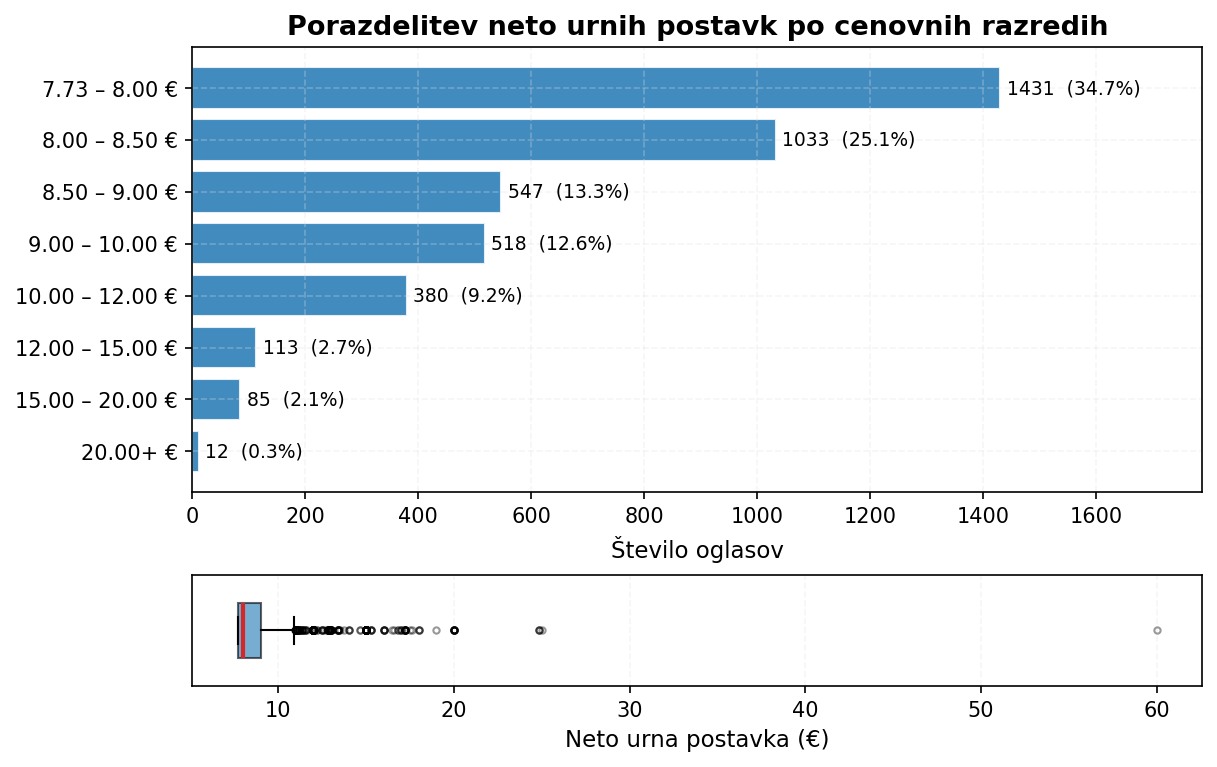

In [4]:
# Filtriramo samo oglase z urnim plačilom
hourly = data[data["normalized_payment_type"] == "HOURLY"].copy()
rates = hourly["hourly_rate_neto"].dropna()
MIN_WAGE = 7.73  # minimalna študentska urna postavka (neto)

# Opisna statistika
stats = rates.describe().to_frame("Neto urna postavka (€)")
stats.index = ["Število oglasov", "Povprečje", "Std. odklon", "Min", "25%", "Mediana (50%)", "75%", "Max"]
display(stats.style.format("{:.2f}"))

# Frekvenčna tabela po cenovnih razredih (od minimalne plače naprej)
bins = [MIN_WAGE, 8, 8.5, 9, 10, 12, 15, 20, 30]
labels = ["7.73 – 8.00 €", "8.00 – 8.50 €", "8.50 – 9.00 €",
          "9.00 – 10.00 €", "10.00 – 12.00 €", "12.00 – 15.00 €",
          "15.00 – 20.00 €", "20.00+ €"]
razredi = pd.cut(rates, bins=bins, labels=labels, right=False)
freq = razredi.value_counts().sort_index().to_frame("Število oglasov")
freq["Delež"] = freq["Število oglasov"] / freq["Število oglasov"].sum()

# Stolpčni graf razredov + box plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), layout="constrained",
                               gridspec_kw={"height_ratios": [4, 1]})

bars = ax1.barh(labels, freq["Število oglasov"], color=COLORS[0], edgecolor="white", alpha=0.85)
ax1.bar_label(bars, labels=[f"{v}  ({p:.1%})" for v, p in zip(freq["Število oglasov"], freq["Delež"])],
              padding=3, fontsize=9)
ax1.set_xlabel("Število oglasov")
ax1.set_title("Porazdelitev neto urnih postavk po cenovnih razredih")
ax1.set_xlim(right=freq["Število oglasov"].max() * 1.25)
ax1.invert_yaxis()

# Box plot pod stolpčnim grafom
bp = ax2.boxplot(rates, vert=False, widths=0.5, patch_artist=True,
                 boxprops=dict(facecolor=COLORS[0], alpha=0.6),
                 medianprops=dict(color=COLORS[3], linewidth=2),
                 flierprops=dict(marker="o", markersize=3, alpha=0.4))
ax2.set_xlabel("Neto urna postavka (€)")
ax2.set_yticks([])

plt.show()

### Število novih oglasov na dan

Koliko novih oglasov se pojavi na portalu vsak dan? Prvi dan zbiranja izpustimo, ker je scraper takrat pobral vse že obstoječe oglase naenkrat.

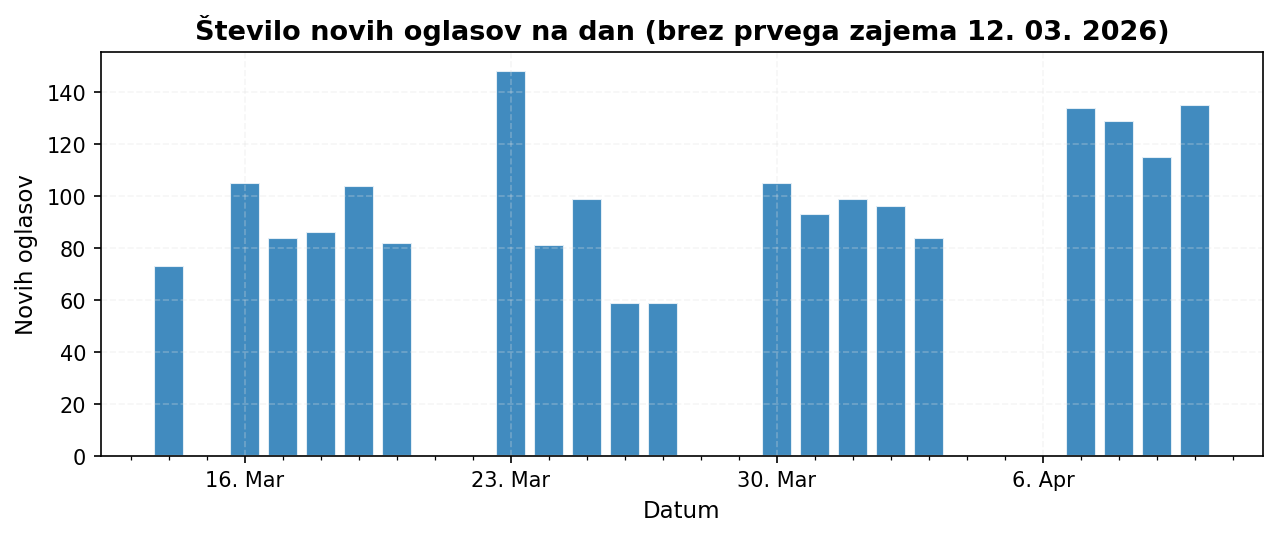

In [5]:
import matplotlib.dates as mdates
import platform

# Število novih oglasov po dnevu (first_seen = kdaj smo oglas prvič videli)
daily_new = data.groupby(data["first_seen"].dt.date).size()

# Izpustimo prvi dan — takrat je scraper pobral vse obstoječe oglase
first_day = daily_new.index.min()
daily_new = daily_new.drop(first_day)

# Pretvorimo datume za matplotlib formatting
dates = pd.to_datetime(daily_new.index)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(dates, daily_new.values, color=COLORS[0], edgecolor="white", alpha=0.85, width=0.8)

# TODO: ob večanju podatkov moramo ustrezno podaljašti inerval prikaza oznake datuma
# Prikažemo vsak 7. dan kot oznako, format "11. mar"
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
fmt = "%#d. %b" if platform.system() == "Windows" else "%-d. %b"  #formatiranje tako deluje pravilno neodvisno od sistema
ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))
ax.xaxis.set_minor_locator(mdates.DayLocator())

ax.set_xlabel("Datum")
ax.set_ylabel("Novih oglasov")
ax.set_title(f"Število novih oglasov na dan (brez prvega zajema {first_day:%d. %m. %Y})")
plt.xticks(rotation=0)
plt.show()

### Oglasi po regijah

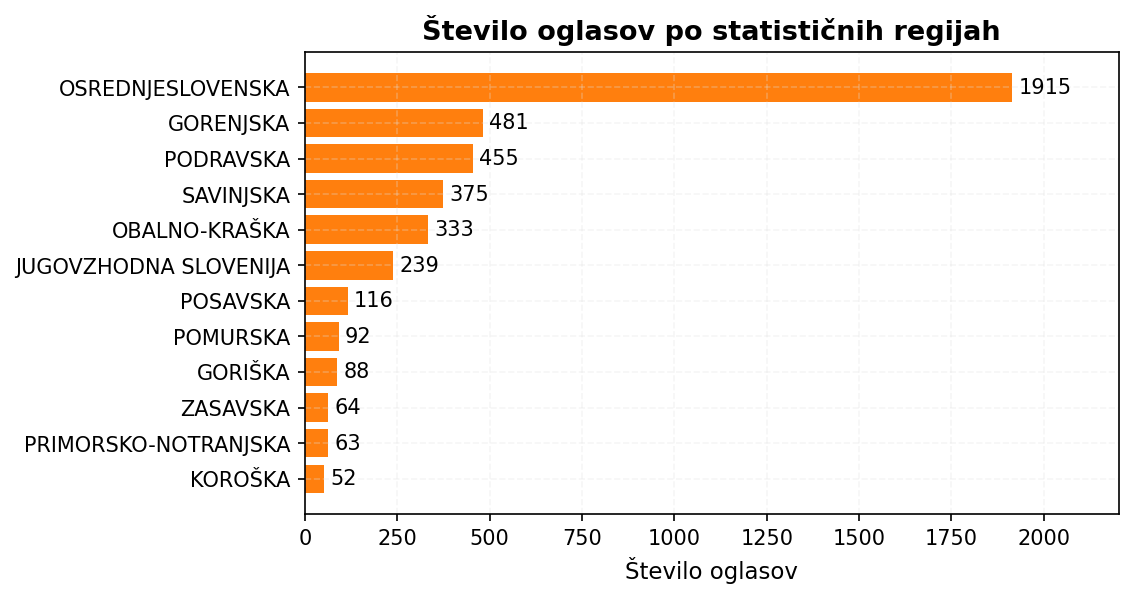

In [6]:
region_counts = data["normalized_region"].value_counts().sort_values()

fig, ax = plt.subplots()
bars = ax.barh(region_counts.index, region_counts.values, color=COLORS[1])
ax.bar_label(bars, padding=3)
ax.set_xlabel("Število oglasov")
ax.set_title("Število oglasov po statističnih regijah")
ax.set_xlim(right=region_counts.max() * 1.15)
plt.show()

### Tipi plačila

Stolpec `normalized_payment_type` razvršča oglase glede na način izplačila:

| Tip | Slovensko         | Pomen |
|---|-------------------|---|
| `HOURLY` | Urna postavka     | Plačilo na uro dela |
| `NEGOTIABLE` | Po dogovoru       | Plačilo ni vnaprej določeno, dogovor med delodajalcem in študentom |
| `PROJECT` | Projektno plačilo | Fiksno plačilo za celoten projekt ali nalogo |
| `PER_EVENT` | Na dogodek        | Plačilo na posamezen dogodek (npr. promocija, animacija) |
| `PER_TRIP` | Na izlet          | Plačilo na izlet |
| `OTHER` | Drugo             | Netipičen ali nerazpoznan način plačila |

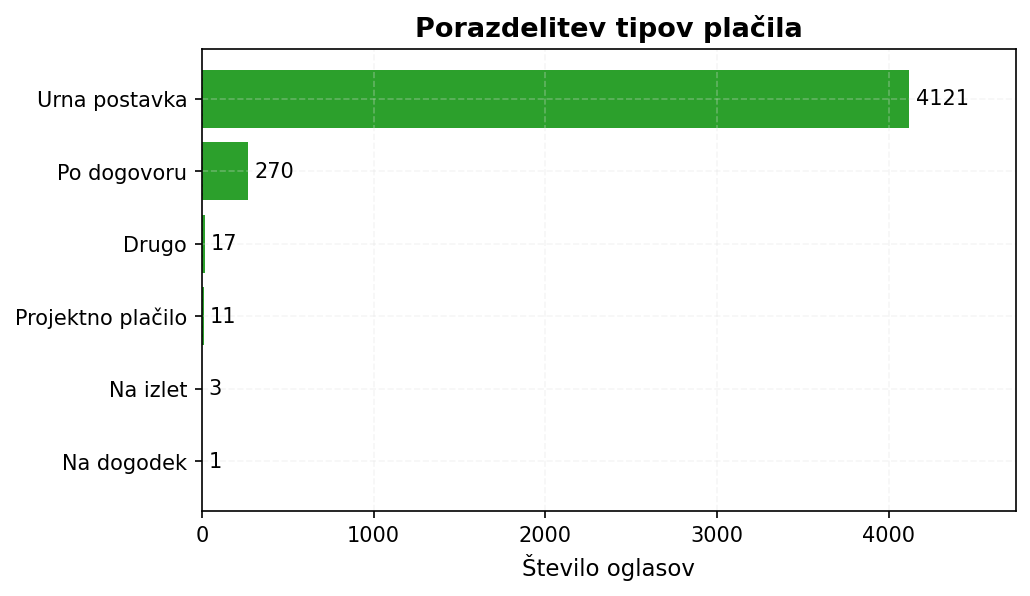

In [7]:
# Mapiramo angleška imena v slovenska
PAYMENT_LABELS = {
    "HOURLY": "Urna postavka",
    "NEGOTIABLE": "Po dogovoru",
    "PROJECT": "Projektno plačilo",
    "PER_EVENT": "Na dogodek",
    "PER_TRIP": "Na izlet",
    "OTHER": "Drugo",
}

payment_counts = data["normalized_payment_type"].map(PAYMENT_LABELS).value_counts().sort_values()

fig, ax = plt.subplots()
bars = ax.barh(payment_counts.index, payment_counts.values, color=COLORS[2])
ax.bar_label(bars, padding=3)
ax.set_xlabel("Število oglasov")
ax.set_title("Porazdelitev tipov plačila")
ax.set_xlim(right=payment_counts.max() * 1.15)
plt.show()

### Top 10 delodajalcev po številu oglasov

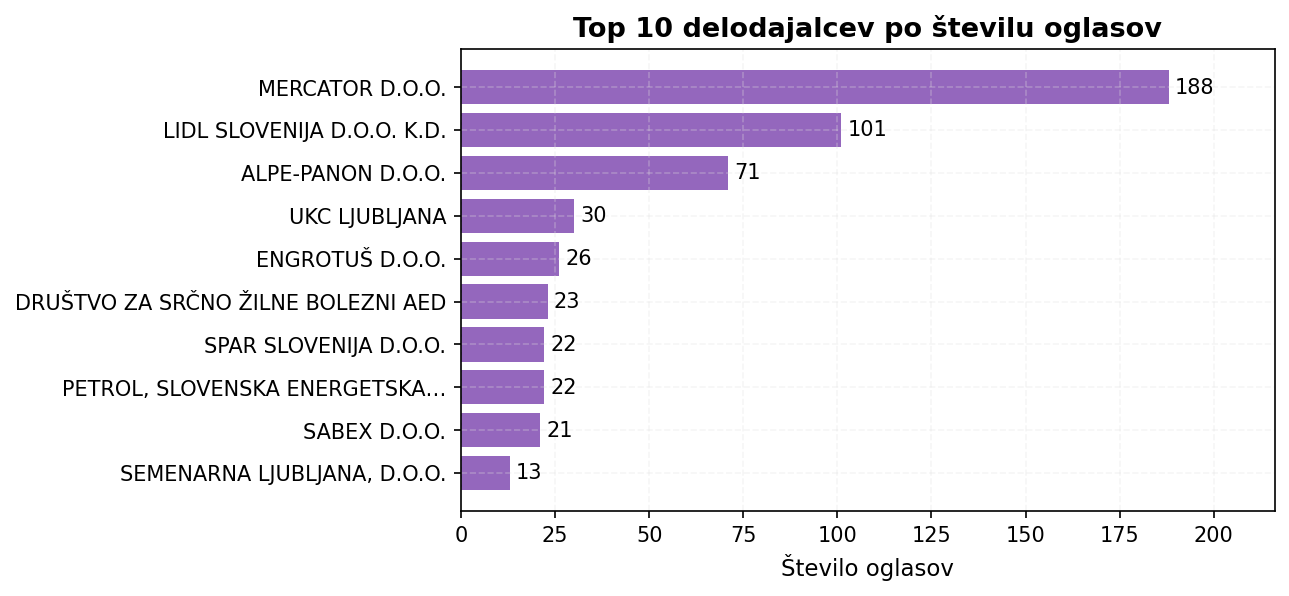

In [8]:
import textwrap

top_companies = data["company"].value_counts().head(10).sort_values()

# Skrajšamo predolga imena (>35 znakov)
short_names = top_companies.index.map(lambda x: textwrap.shorten(x, width=35, placeholder="…"))

fig, ax = plt.subplots()
bars = ax.barh(short_names, top_companies.values, color=COLORS[4])
ax.bar_label(bars, padding=3)
ax.set_xlabel("Število oglasov")
ax.set_title("Top 10 delodajalcev po številu oglasov")
ax.set_xlim(right=top_companies.max() * 1.15)
plt.show()

### Delovni čas

Kako so oglasi porazdeljeni glede na delovni čas? Stolpec `work_schedule` označuje, kdaj se delo izvaja — dopoldan, popoldan, izmensko, med vikendi ali po dogovoru.

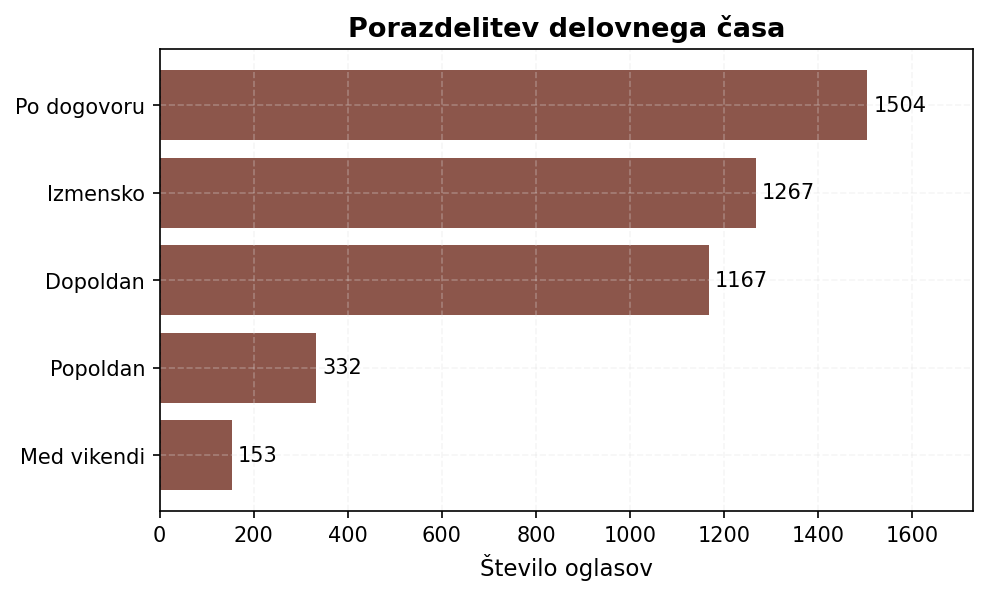

In [9]:
# Porazdelitev delovnega časa
SCHEDULE_LABELS = {
    "PO DOGOVORU": "Po dogovoru",
    "DOPOLDAN": "Dopoldan",
    "POPOLDAN": "Popoldan",
    "IZMENSKO": "Izmensko",
    "MED VIKENDI": "Med vikendi",
}

schedule_counts = data["work_schedule"].map(SCHEDULE_LABELS).value_counts().sort_values()

fig, ax = plt.subplots()
bars = ax.barh(schedule_counts.index, schedule_counts.values, color=COLORS[5])
ax.bar_label(bars, padding=3)
ax.set_xlabel("Število oglasov")
ax.set_title("Porazdelitev delovnega časa")
ax.set_xlim(right=schedule_counts.max() * 1.15)
plt.show()

### Število prostih mest

Vsak oglas ima lahko podatek o številu prostih mest (`open_positions`). To pove, koliko študentov delodajalec dejansko išče — en oglas lahko pomeni povpraševanje po več delavcih.

In [10]:
# Število prostih mest — koliko študentov dejansko iščejo
positions = data["open_positions"].dropna()

povzetek_mest = pd.DataFrame({
    "Metrika": [
        "Oglasov s podatkom o prostih mestih",
        "Skupno prostih mest",
        "Povprečje na oglas",
        "Mediana na oglas",
        "Največ prostih mest v enem oglasu",
    ],
    "Vrednost": [
        f"{len(positions):,.0f} od {len(data):,.0f} ({len(positions) / len(data) * 100:.0f}%)",
        f"{positions.sum():,.0f}",
        f"{positions.mean():.1f}",
        f"{positions.median():.0f}",
        f"{positions.max():.0f}",
    ],
})
display(povzetek_mest.style.hide(axis="index").set_properties(**{"text-align": "left"}))

# Top 10 oglasov z največ prostimi mesti
top_positions = (
    data.dropna(subset=["open_positions"])
    .nlargest(10, "open_positions")
    [["title", "company", "normalized_city", "open_positions"]]
    .rename(columns={
        "title": "Naslov", "company": "Delodajalec",
        "normalized_city": "Mesto", "open_positions": "Prostih mest",
    })
)
top_positions["Naslov"] = top_positions["Naslov"].apply(
    lambda x: textwrap.shorten(x, 50) if isinstance(x, str) else x)
top_positions["Delodajalec"] = top_positions["Delodajalec"].apply(
    lambda x: textwrap.shorten(x, 35) if isinstance(x, str) else x)

display(Markdown("#### Top 10 oglasov z največ prostimi mesti"))
display(top_positions.style.hide(axis="index").format({"Prostih mest": "{:.0f}"}, na_rep="Ni podatka"))

Metrika,Vrednost
Oglasov s podatkom o prostih mestih,"2,082 od 4,423 (47%)"
Skupno prostih mest,"7,054"
Povprečje na oglas,3.4
Mediana na oglas,2
Največ prostih mest v enem oglasu,40


#### Top 10 oglasov z največ prostimi mesti

Naslov,Delodajalec,Mesto,Prostih mest
RAZISKOVALNO DELO,PEDAGOŠKI INŠTITUT,Ni podatka,40
STATIST,"CUT PRODUCTION, TV [...]",LJUBLJANA,30
DELO V KUHINJI,ALPE-PANON D.O.O.,PTUJ,25
DELO S STRANKAMI,ALPE-PANON D.O.O.,PTUJ,25
STREŽBA,VANUM'S D.O.O.,ZREČE,20
DELO Z OTROKI,VARNA POT,LJUBLJANA,20
ANIMATOR/KA,VARNA POT,LJUBLJANA,20
PROMOCIJA,VARNA POT,Ni podatka,20
BLAGAJNIK,"GLOBAL FAST FOOD S, D.O.O.",CELJE,20
DELO V TURIZMU,RELAX TURIZEM D.D.,Ni podatka,20


### Top 10 mest po številu oglasov

Podrobnejši pogled na lokacijo oglasov — namesto statističnih regij pogledamo posamezna mesta (`normalized_city`).

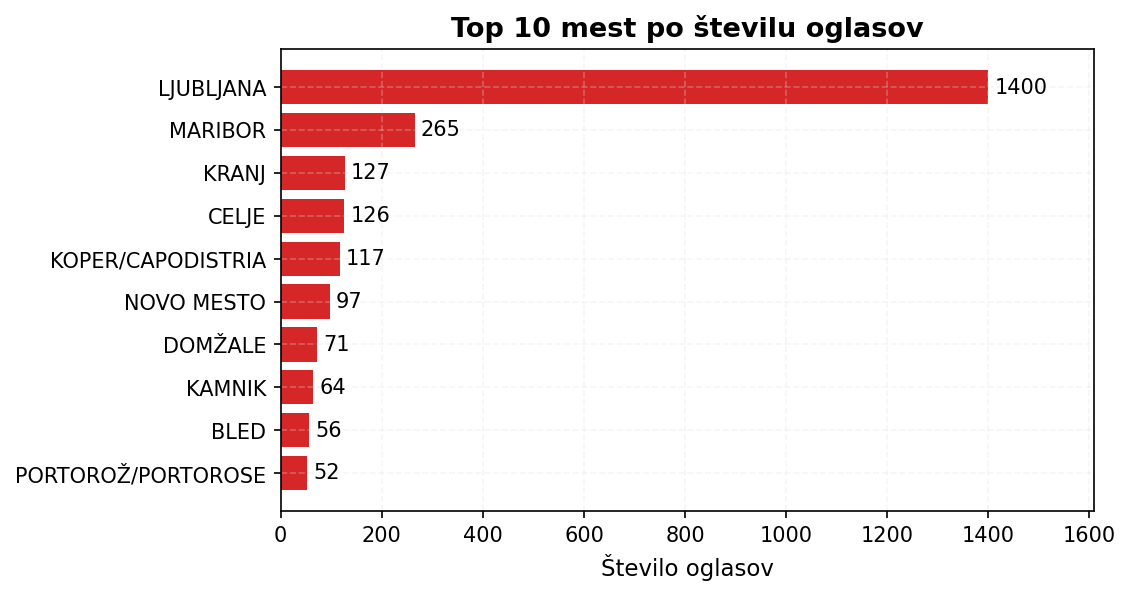

In [11]:
# Top 10 mest po številu oglasov
city_counts = data["normalized_city"].value_counts().head(10).sort_values()

fig, ax = plt.subplots()
bars = ax.barh(city_counts.index, city_counts.values, color=COLORS[3])
ax.bar_label(bars, padding=3)
ax.set_xlabel("Število oglasov")
ax.set_title("Top 10 mest po številu oglasov")
ax.set_xlim(right=city_counts.max() * 1.15)
plt.show()

---

# Vprašanja

Vsako vprašanje sledi enaki strukturi: **naslov**, **opis**, **analiza**, **vizualizacija** in **ugotovitve**.

## Template za vprašanja

Vsako vprašanje v razdelku **Vprašanja** mora slediti spodnji strukturi:

```
## Vprašanje [N]: [Kratek, jasen naslov]

### Opis
Kaj točno raziskujemo? Zakaj je to vprašanje relevantno? Katere stolpce/podatke
uporabljamo in kakšna je hipoteza, če jo imamo?

### Analiza
[code celica — priprava podatkov, izračuni, tabele]

### Vizualizacija
[code celica — grafi]

### Ugotovitve
- Kaj smo ugotovili?
- Ali se hipoteza potrdi ali ne?
- Kakšne so omejitve analize?
```

## Vprašanje 1: Popularnost programskih (in ostalih) jezikov v opisih oglasov

### Opis

Zanima nas, kateri programski (in ostali) jeziki se najpogosteje pojavljajo v besedilnih opisih študentskih oglasov. S preprosto regex analizo polja `description` iščemo omembe 10 popularnih jezikov (Python, JavaScript, Java, C++, C#, PHP, SQL, TypeScript, HTML, CSS). Rezultat je groba ocena povpraševanja po posameznih jezikih na trgu študentskega dela.

**Omejitev:** Analiza šteje le eksplicitne omembe — oglas za "spletno programiranje" brez navedbe jezika ne bo zajet.

### Analiza

In [12]:
# Regex vzorci za 10 popularnih jezikov
# \b = word boundary, (?!\w) = ne sme slediti črka/številka
# C# in C++ potrebujeta (?!\w) namesto \b ker # in + niso word characters
# [aeiou]? na koncu ujame slovenske sklone (Pythona, Javo, ...)
# Kratice (HTML, CSS, ...) dobijo (?:j?[aeiou])? ker se sklanjajo z j: HTMLja, CSSju
# SQL ujame tudi MySQL, PostgreSQL in MariaDB — vse štejemo pod "SQL"
# JavaScript ujame tudi Node.js / NodeJS — isti jezik, drug runtime
languages = {
    "Python": r"\bPython[aeiou]?\b",
    "JavaScript": r"\bJavaScript[aeiou]?\b|\bNode(?:\.?js|JS)\b",
    "PHP": r"\bPHP(?:j?[aeiou])?\b",
    "SQL": r"\b(?:My|Postgre)?SQL(?:j?[aeiou])?\b|\bMariaDB\b",
    "Java": r"\bJav[aeiou]\b(?!Script)",  # Java/Javo/Jave/Javi — vedno ima samoglasnik
    "C#": r"\bC#(?![a-zA-Z0-9])",  # \b ne deluje za # ker ni word char
    "C++": r"\bC\+\+(?![a-zA-Z0-9])",  # isto za +
    "TypeScript": r"\bTypeScript[aeiou]?\b",
    "HTML": r"\bHTML(?:j?[aeiou])?\b",
    "CSS": r"\bCSS(?:j?[aeiou])?\b",
}

# Preštejemo v koliko oglasih se pojavi vsak jezik (case-insensitive)
desc = data["description"].fillna("")
counts = {
    lang: desc.str.contains(pat, case=False, regex=True).sum()
    for lang, pat in languages.items()
}

# Rezultat kot DataFrame, sortirano naraščajoče za barh graf
lang_df = (
    pd.DataFrame.from_dict(counts, orient="index", columns=["count"])
    .sort_values("count", ascending=True)
)
lang_df = lang_df[lang_df["count"] > 0]  # prikažemo samo jezike ki se dejansko pojavljajo

lang_df

,count
PHP,2
TypeScript,2
CSS,5
C#,6
HTML,6
C++,7
JavaScript,8
SQL,9
Python,16
Java,23


In [13]:
# Koliko oglasov omenja vsaj en programski jezik?
combined_pattern = "|".join(languages.values())
total_with_lang = desc.str.contains(combined_pattern, case=False, regex=True).sum()

povzetek = pd.DataFrame({
    "Metrika": [
        "Oglasov z omembo vsaj enega jezika",
        "Delež vseh oglasov",
        "Najbolj iskan jezik",
    ],
    "Vrednost": [
        f"{total_with_lang} od {len(data)}",
        f"{total_with_lang / len(data) * 100:.1f}%",
        f"{lang_df.index[-1]} ({lang_df['count'].iloc[-1]} oglasov)",
    ],
})
display(povzetek.style.hide(axis="index").set_properties(**{"text-align": "left"}))

Metrika,Vrednost
Oglasov z omembo vsaj enega jezika,47 od 4423
Delež vseh oglasov,1.1%
Najbolj iskan jezik,Java (23 oglasov)


### Vizualizacija

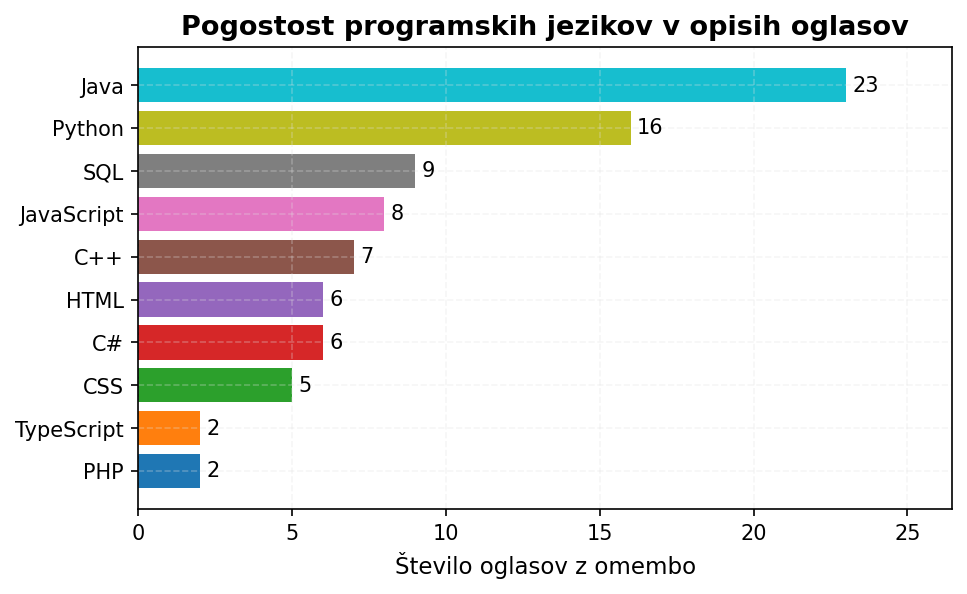

In [14]:
# Horizontalni stolpčni graf — vsak jezik svoja barva za boljšo ločljivost
fig, ax = plt.subplots()
bars = ax.barh(lang_df.index, lang_df["count"], color=COLORS[: len(lang_df)])
ax.bar_label(bars, padding=3)
ax.set_xlabel("Število oglasov z omembo")
ax.set_title("Pogostost programskih jezikov v opisih oglasov")
ax.set_xlim(right=lang_df["count"].max() * 1.15)
plt.show()

### Ugotovitve

- Kateri jezik prevladuje in zakaj je to pričakovano/presenetljivo?
- Kolikšen delež oglasov sploh omenja programski jezik?

## Vprašanje 2: Ali delodajalci dvigujejo plače, ko oglasa ne morejo zapolniti?

### Opis

Datoteka `changes.csv` beleži vsako spremembo polja na obstoječem oglasu. Če delodajalec po objavi dvigne urno postavko (`hourly_rate_neto`), je to signal, da prvotna ponudba ni pritegnila dovolj kandidatov.

Analiziramo:
- Koliko oglasov je doživelo dvig plače in koliko znižanje?
- Po koliko dneh od objave se tipično zgodi dvig?
- Za koliko se plača dvigne — minimalen popravek ali občuten skok?

**Hipoteza:** Večina sprememb bo dvigov (ne znižanj), do katerih pride v prvih dneh po objavi.

### Analiza

In [15]:
# Iz changes.csv izvlečemo samo spremembe urne postavke
rate_changes = changes[changes["field"] == "hourly_rate_neto"].copy()

# Pretvorimo staro in novo vrednost v številke
rate_changes["old_value"] = pd.to_numeric(rate_changes["old_value"], errors="coerce")
rate_changes["new_value"] = pd.to_numeric(rate_changes["new_value"], errors="coerce")
rate_changes = rate_changes.dropna(subset=["old_value", "new_value"])

# Izračunamo razliko (pozitivna = dvig, negativna = znižanje)
rate_changes["diff"] = rate_changes["new_value"] - rate_changes["old_value"]

# Koliko dni po prvi objavi oglasa je prišlo do spremembe
rate_changes = rate_changes.merge(
    data[["id", "first_seen"]],
    left_on="listing_id", right_on="id", how="left"
)
rate_changes["days_after_post"] = (rate_changes["changed_at"] - rate_changes["first_seen"]).dt.days

# Ločimo dvige in znižanja
raises = rate_changes[rate_changes["diff"] > 0]
cuts = rate_changes[rate_changes["diff"] < 0]

# Povzetek v tabeli
povzetek = pd.DataFrame({
    "Metrika": [
        "Sprememb urne postavke skupaj",
        "Dvigov plače",
        "Znižanj plače",
        "Povprečen dvig (€)",
        "Mediana dni do dviga",
    ],
    "Vrednost": [
        f"{len(rate_changes)}",
        f"{len(raises)} ({len(raises) / len(rate_changes) * 100:.0f}%)" if len(rate_changes) > 0 else "0",
        f"{len(cuts)} ({len(cuts) / len(rate_changes) * 100:.0f}%)" if len(rate_changes) > 0 else "0",
        f"{raises['diff'].mean():.2f} €" if len(raises) > 0 else "—",
        f"{raises['days_after_post'].median():.0f} dni" if len(raises) > 0 else "—",
    ],
})
display(povzetek.style.hide(axis="index").set_properties(**{"text-align": "left"}).format(na_rep="Ni podatka"))

Metrika,Vrednost
Sprememb urne postavke skupaj,87
Dvigov plače,87 (100%)
Znižanj plače,0 (0%)
Povprečen dvig (€),0.96 €
Mediana dni do dviga,15 dni


### Vizualizacija

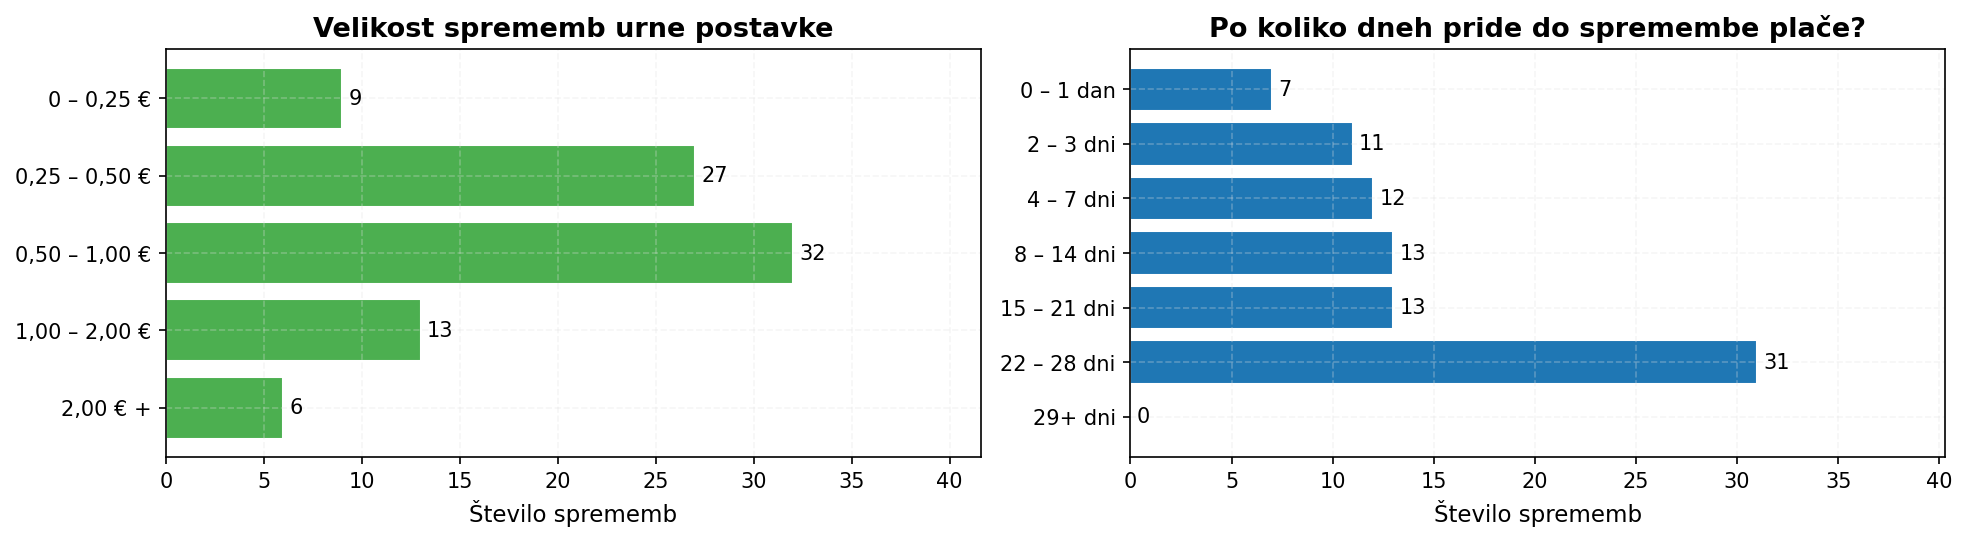

#### Top 10 največjih dvigov

Naslov,Delodajalec,Prej (€),Potem (€),Dvig (€),Dni po objavi
ČIŠČENJE,"ARTHA 9, INOVATIVNE REŠITVE, D.O.O.",12.00,18.00,+6.00,15
ČIŠČENJE,"ARTHA 9, INOVATIVNE REŠITVE, D.O.O.",12.00,18.00,+6.00,15
DELO NA BENCINSKEM SERVISU,POSREDNIŠTVO PRI PRODAJI UROŠ [...],10.00,13.00,+3.00,24
DELO NA TERENU,"ENERGETIKA LJUBLJANA, D.O.O.",7.74,10.33,+2.59,10
DELO S STRANKAMI,"GLOBAL FAST FOOD S, D.O.O.",8.17,10.76,+2.59,3
BLAGAJNIK,LAGARDERE TRAVEL RETAIL [...],7.74,9.90,+2.16,15
STREŽBA,"PREVOZI, ŠPEDICIJA IN [...]",8.00,10.00,+2.00,3
DELO V ZDRAVSTVU,KIRURGIJA ERNEST NOVAK S.P.,8.00,10.00,+2.00,7
STREŽBA HRANE IN PIJAČE,LIR D.O.O.,8.00,10.00,+2.00,17
STREŽBA,"POSREDNIŠTVO PRI PRODAJI, [...]",10.00,12.00,+2.00,6


In [16]:
# --- Graf 1: Velikost sprememb urne postavke (intervali) ---
bins_size = [0, 0.25, 0.50, 1.00, 2.00, float("inf")]
labels_size = ["0 – 0,25 €", "0,25 – 0,50 €", "0,50 – 1,00 €", "1,00 – 2,00 €", "2,00 € +"]

# --- Graf 2: Po koliko dneh pride do spremembe ---
bins_days = [-1, 1, 3, 7, 14, 21, 28, float("inf")]
labels_days = [
    "0 – 1 dan",
    "2 – 3 dni",
    "4 – 7 dni",
    "8 – 14 dni",
    "15 – 21 dni",
    "22 – 28 dni",
    "29+ dni"
]

if len(rate_changes) > 0:
    # Razdelimo spremembe v intervale glede na absolutno vrednost
    rate_changes["abs_diff"] = rate_changes["diff"].abs()
    rate_changes["interval_size"] = pd.cut(rate_changes["abs_diff"], bins=bins_size, labels=labels_size, right=True)
    rate_changes["interval_days"] = pd.cut(rate_changes["days_after_post"], bins=bins_days, labels=labels_days,
                                           right=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.5), layout="constrained")

    # --- Levi graf: velikost sprememb ---
    raises_binned = rate_changes[rate_changes["diff"] > 0].groupby("interval_size", observed=False).size()
    cuts_binned = rate_changes[rate_changes["diff"] < 0].groupby("interval_size", observed=False).size()

    bars_r = ax1.barh(labels_size, raises_binned.values, color="#4CAF50", edgecolor="white", label="Dvig ↑")
    ax1.bar_label(bars_r, padding=3, fontsize=10)

    if cuts_binned.sum() > 0:
        bars_c = ax1.barh(labels_size, cuts_binned.values, left=raises_binned.values,
                          color="#E53935", edgecolor="white", label="Znižanje ↓")
        ax1.bar_label(bars_c, padding=3, fontsize=10)
        ax1.legend(loc="lower right")

    ax1.set_xlabel("Število sprememb")
    ax1.set_title("Velikost sprememb urne postavke")
    ax1.set_xlim(right=max(raises_binned.max(), 1) * 1.3)
    ax1.invert_yaxis()

    # --- Desni graf: dni do spremembe ---
    days_binned = rate_changes.groupby("interval_days", observed=False).size()

    bars_d = ax2.barh(labels_days, days_binned.values, color=COLORS[0], edgecolor="white")
    ax2.bar_label(bars_d, padding=3, fontsize=10)
    ax2.set_xlabel("Število sprememb")
    ax2.set_title("Po koliko dneh pride do spremembe plače?")
    ax2.set_xlim(right=max(days_binned.max(), 1) * 1.3)
    ax2.invert_yaxis()

    plt.show()

    # --- Tabela top 10 največjih dvigov ---
    if len(raises) > 0:
        import textwrap

        primeri = (
            raises.merge(data[["id", "title", "company"]], left_on="listing_id", right_on="id", how="left")
            .sort_values("diff", ascending=False)
            [["title", "company", "old_value", "new_value", "diff", "days_after_post"]]
            .head(10)
            .rename(columns={
                "title": "Naslov", "company": "Delodajalec",
                "old_value": "Prej (€)", "new_value": "Potem (€)",
                "diff": "Dvig (€)", "days_after_post": "Dni po objavi",
            })
        )
        primeri["Naslov"] = primeri["Naslov"].apply(lambda x: textwrap.shorten(x, 50) if isinstance(x, str) else x)
        primeri["Delodajalec"] = primeri["Delodajalec"].apply(
            lambda x: textwrap.shorten(x, 35) if isinstance(x, str) else x)
        display(Markdown("#### Top 10 največjih dvigov"))
        display(primeri.style.hide(axis="index").format(
            {"Prej (€)": "{:.2f}", "Potem (€)": "{:.2f}", "Dvig (€)": "+{:.2f}", "Dni po objavi": "{:.0f}"},
            na_rep="Ni podatka"))
else:
    display(Markdown("*V podatkih ni sprememb urne postavke.*"))

### Ugotovitve

- Koliko delodajalcev je dvignilo plačo in ali je to pogost pojav?
- Po koliko dneh se tipično zgodi dvig — je to znak "obupa"?
- Kakšna je povprečna velikost dviga?

## Vprašanje 3: Kje so študentska dela najbolje plačana?

### Opis

Primerjamo mediano neto urne postavke po 12 statističnih regijah Slovenije. Uporabljamo samo oglase s tipom plačila `HOURLY` in znano regijo (`normalized_region`). Za vsako regijo izračunamo mediano, povprečje in število oglasov.

Zanima nas:
- Ali obstaja geografska plačna vrzel med regijami?
- Koliko bolje je plačano delo v Ljubljani / na Obali v primerjavi s preostalo Slovenijo?
- Ali imajo regije z malo oglasi zanesljive ocene?

**Vizualizacija:** Regije pod skupno mediano so obarvane rdeče, nad njo zeleno.

### Analiza

In [17]:
# Filtriramo na oglase z urnim plačilom, znano regijo in urno postavko
hourly_regional = data[
    (data["normalized_payment_type"] == "HOURLY") &
    (data["normalized_region"].notna()) &
    (data["hourly_rate_neto"].notna())
    ].copy()

# Mediana, povprečje in število oglasov po regiji
region_pay = (
    hourly_regional.groupby("normalized_region")["hourly_rate_neto"]
    .agg(["median", "mean", "count"])
    .rename(columns={"median": "Mediana (€)", "mean": "Povprečje (€)", "count": "Št. oglasov"})
    .sort_values("Mediana (€)")
)

# Skupna mediana za primerjavo (čez vse regije)
overall_median = hourly_regional["hourly_rate_neto"].median()
region_pay["Razlika od mediane"] = region_pay["Mediana (€)"] - overall_median

display(Markdown(f"Skupna mediana neto urne postavke: **{overall_median:.2f} €**"))
display(region_pay.style.format({
    "Mediana (€)": "{:.2f}",
    "Povprečje (€)": "{:.2f}",
    "Št. oglasov": "{:.0f}",
    "Razlika od mediane": "{:+.2f}",
}, na_rep="Ni podatka"))

Skupna mediana neto urne postavke: **8.00 €**

,Mediana (€),Povprečje (€),Št. oglasov,Razlika od mediane
normalized_region,,,,
ZASAVSKA,7.73,8.04,59,-0.27
KOROŠKA,7.74,8.53,49,-0.26
PODRAVSKA,8.00,8.35,418,+0.00
JUGOVZHODNA SLOVENIJA,8.00,8.46,224,+0.00
POMURSKA,8.00,8.45,84,+0.00
PRIMORSKO-NOTRANJSKA,8.00,8.43,62,+0.00
POSAVSKA,8.00,8.37,111,+0.00
OBALNO-KRAŠKA,8.00,8.55,312,+0.00
SAVINJSKA,8.00,8.59,355,+0.00


### Vizualizacija

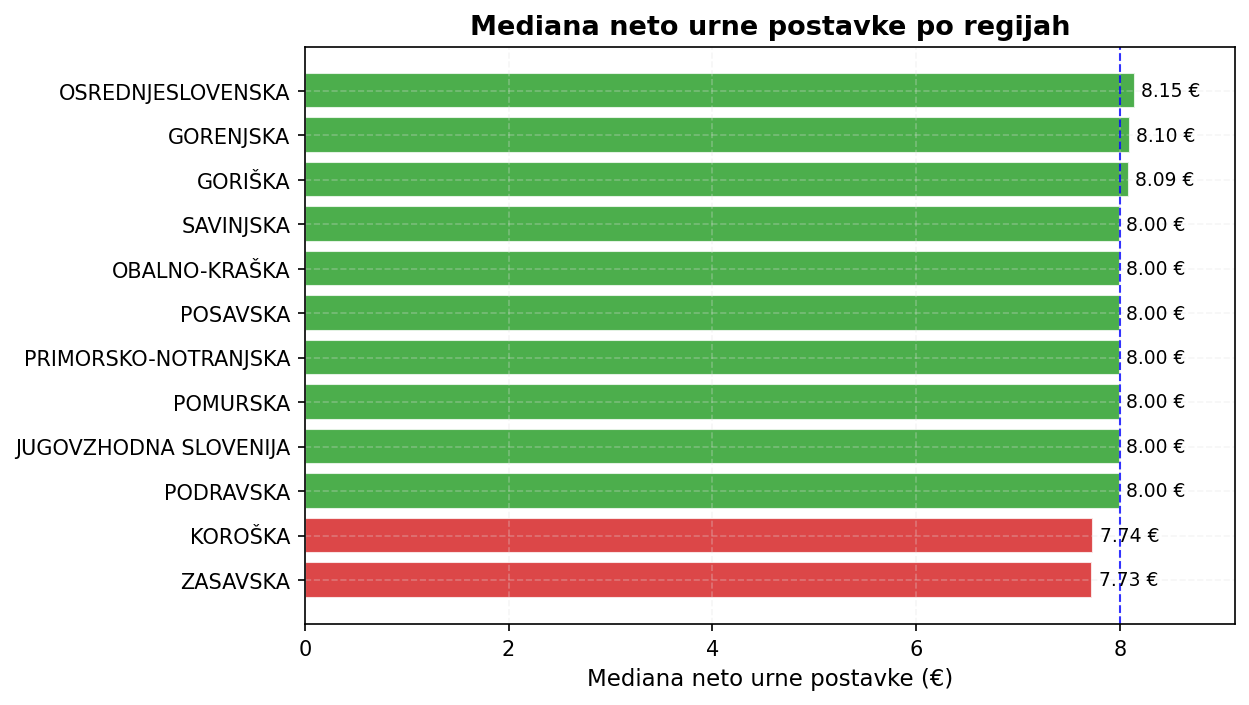

In [18]:
# Horizontalni stolpčni graf median po regijah
# Rdeče = pod skupno mediano, zeleno = nad
fig, ax = plt.subplots(figsize=(8, 5))

colors_region = [COLORS[3] if v < overall_median else COLORS[2] for v in region_pay["Mediana (€)"]]
bars = ax.barh(region_pay.index, region_pay["Mediana (€)"], color=colors_region, edgecolor="white", alpha=0.85)
ax.bar_label(bars, labels=[f"{v:.2f} €" for v in region_pay["Mediana (€)"]], padding=3, fontsize=9)

# Črtkana črta za skupno mediano z anotacijo ob spodnjem robu
ax.axvline(overall_median, color="blue", linestyle="--", linewidth=1, alpha=0.8)
#ax.annotate(f"  {overall_median:.2f} €\n  (mediana)",
#            xy=(overall_median, len(region_pay) - 0.5),
#            fontsize=8, fontstyle="italic", va="top")

ax.set_xlabel("Mediana neto urne postavke (€)")
ax.set_title("Mediana neto urne postavke po regijah")
ax.set_xlim(right=region_pay["Mediana (€)"].max() * 1.12)
plt.show()

### Ugotovitve

- Katera regija ima najvišjo mediano in ali je to pričakovano?
- Kako velika je razlika med najbolje in najslabše plačano regijo?
- Ali število oglasov v regiji vpliva na zanesljivost ocene (majhne regije z malo oglasi)?

## Vprašanje 4: Kako se trajanje študentskega dela razlikuje glede na vrsto dela?

### Opis
Raziskujemo, ali se in kako se trajanje študentskega dela razlikuje glede na vrsto dela (pridobimo najpogostejše vrste dela glede na ime npr. pomoč v trgovini, IT, strežba).

Študentom, ki si aktivno iščejo delo, lahko to pove v katerih panogah lahko preko študentskega servisa pričakujejo bolj dolgoročno delo in pri katerih delih je čas trajanja bolj prilagodljiv. 

Zanima nas:
- Ali obstajajo jasni vzorci med vrsto dela in časom trajanja? 
- Katere vrste dela so najbolj dolgotrajne?
- Pri katerih vrstah dela je čas trajanja najbolj prilagodljiv?

Uporabimo bomo atribut `duration` za določanje trajnosti dela, ter atributa `title` in `subtitle` za določanje vrste dela.  


### Analiza


In [19]:
duration = data["duration"].str.upper().fillna("")


def map_duration(d):
    if "DLJE ČASA" in d:
        return "DLJE ČASA"
    elif "PO DOGOVORU" in d:
        return "PO DOGOVORU"
    else:
        return "OSTALO"


titles = (data["title"].fillna("") + " " + data["subtitle"].fillna("")).str.upper()


def categorize(title):
    if "PROGRAMIRANJE" in title or "IT" in title:
        return "IT"
    elif "STREŽBA" in title or "KUHINJI" in title:
        return "GOSTINSTVO"
    elif "TRGOVINI" in title or "PRODAJA" in title or "BLAGAJNIK" in title:
        return "PRODAJA"
    elif "ADMINISTRATIVNA" in title or "ADMINISTRACIJA" in title:
        return "ADMINISTRACIJA"
    elif "PROIZVODNJI" in title or "PROIZVODNJA" in title:
        return "PROIZVODNJA"
    else:
        return "OSTALO"


data["category"] = titles.map(categorize)

data["trajanje"] = duration.map(map_duration)


def make_table(df):
    counts = df["trajanje"].value_counts()
    total = len(df)

    result = pd.DataFrame({
        "stevilo": counts,
        "delež (%)": (counts / total * 100).round(2)
    })

    return result


categories = ["GOSTINSTVO", "PRODAJA", "ADMINISTRACIJA", "PROIZVODNJA", "IT"]
table_data = {}
row_names = ["SPLOŠNO"] + categories
for name in row_names:
    if name == "SPLOŠNO":  #splošno -> vsa dela(da bomo imeli za primerjavo odstopanja pri specifičnih vrstah)
        df = data
    else:
        df = data[data["category"] == name]
    total = len(df)
    counts = df["trajanje"].value_counts().reindex(["DLJE ČASA", "PO DOGOVORU", "OSTALO"], fill_value=0)
    percentages = (counts / total * 100).round(2) if total > 0 else pd.Series([0.0] * 3,
                                                                              index=["DLJE ČASA", "PO DOGOVORU",
                                                                                     "OSTALO"])
    formatted = {
        "Dlje časa": f"{int(counts['DLJE ČASA'])} ({percentages['DLJE ČASA']:.2f}%)".replace(".", ","),
        "Po dogovoru": f"{int(counts['PO DOGOVORU'])} ({percentages['PO DOGOVORU']:.2f}%)".replace(".", ","),
        "Ostalo": f"{int(counts['OSTALO'])} ({percentages['OSTALO']:.2f}%)".replace(".", ","),
        "Skupaj": int(total)
    }
    table_data[name] = formatted

result_table = pd.DataFrame(table_data).T
display(result_table)

,Dlje časa,Po dogovoru,Ostalo,Skupaj
SPLOŠNO,"2978 (67,33%)","1180 (26,68%)","265 (5,99%)",4423
GOSTINSTVO,"767 (71,82%)","275 (25,75%)","26 (2,43%)",1068
PRODAJA,"351 (58,60%)","237 (39,57%)","11 (1,84%)",599
ADMINISTRACIJA,"160 (85,11%)","25 (13,30%)","3 (1,60%)",188
PROIZVODNJA,"95 (74,22%)","27 (21,09%)","6 (4,69%)",128
IT,"248 (73,37%)","76 (22,49%)","14 (4,14%)",338


### Vizualizacija

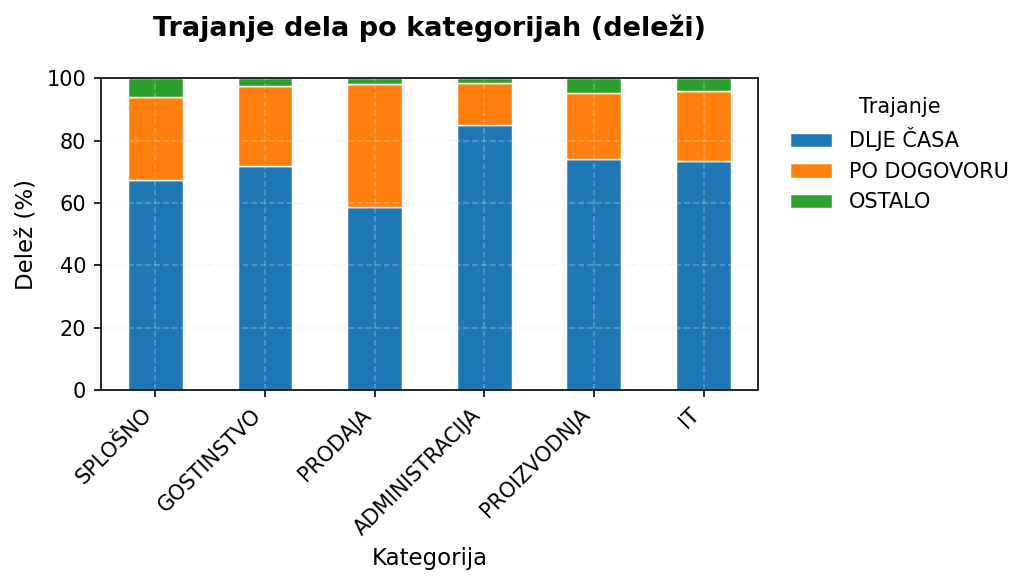

In [20]:
pivot_pct = result_table[["Dlje časa", "Po dogovoru", "Ostalo"]].copy()
#pretvorba deležev v float
pivot_pct = pivot_pct.apply(lambda col: col.astype(str)
                            .str.extract(r'\((.*?)%\)', expand=False)
                            .str.replace(',', '.')
                            .astype(float))

pivot_pct.columns = ["DLJE ČASA", "PO DOGOVORU", "OSTALO"]

category_order = ["SPLOŠNO", "GOSTINSTVO", "PRODAJA", "ADMINISTRACIJA", "PROIZVODNJA", "IT"]
pivot_pct = pivot_pct.reindex(category_order)

plot_data = pivot_pct.dropna(how='all')

ax = plot_data.plot(
    kind="bar",
    stacked=True,
    color=COLORS[:3],
    edgecolor='white',
    linewidth=0.7
)

plt.title("Trajanje dela po kategorijah (deleži)", pad=20)
plt.xlabel("Kategorija")
plt.ylabel("Delež (%)")
plt.ylim(0, 100)

plt.legend(
    title="Trajanje",
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Ugotovitve
- Katere vrste dela so najbolj dolgotrajne? 
- Katere vrste del imajo najbolj prilagodljiv čas trajanja? [prodaja]
- Ena od glavnih omejitev je, da sta na študentskem servisu samo dve glavni in dovolj številčni vrsti trajanja dela(dlje časa in po dogovoru), v primeru, da bi jih bilo več bi bila analiza lahko natančnejša   

## Vprašanje 5: Ali določeni dnevi v tednu prinašajo več novih oglasov?

### Opis
Raziskujemo, ali so določeni dnevi v tednu bolj "aktivni" za objavo novih študentskih del. Študentom, ki si aktivno iščejo delo, lahko ta informacija pomaga, da spremljajo portal ob pravih dnevih in se prijavijo med prvimi.

Uporabimo stolpec `first_seen`, tako da iz datuma izluščimo dan v tednu in izračunamo povprečno število novih oglasov za vsak dan. Izpustimo prvi dan zajema, saj je takrat scraper pobral vse obstoječe oglase.

**Hipoteza:** Med tednom (ponedeljek–petek) je več novih oglasov kot ob vikendih.

### Analiza

In [21]:
# Število novih oglasov po dnevu (first_seen = kdaj smo oglas prvič videli)
daily_new_v5 = data.groupby(data["first_seen"].dt.date).size()

# Izpustimo prvi dan — takrat je scraper pobral vse obstoječe oglase
first_day_v5 = daily_new_v5.index.min()
daily_new_v5 = daily_new_v5.drop(first_day_v5)

# 14.3.2026 (sobota) je scraper pobral petkov zajem, ker v petek ni bil pognan.
# Prestavimo te oglase na petek 13.3.2026.
from datetime import date

sat = date(2026, 3, 14)
fri = date(2026, 3, 13)
if sat in daily_new_v5.index:
    daily_new_v5[fri] = daily_new_v5.get(fri, 0) + daily_new_v5[sat]
    daily_new_v5[sat] = 0

# Ustvarimo polni date range (vključno z dnevi brez novih oglasov)
full_range = pd.date_range(daily_new_v5.index.min(), daily_new_v5.index.max(), freq="D")
daily_new_v5 = daily_new_v5.reindex(full_range.date, fill_value=0)

# Dodamo dan v tednu (0 = ponedeljek, 6 = nedelja)
daily_df = pd.DataFrame({"date": daily_new_v5.index, "count": daily_new_v5.values})
daily_df["weekday"] = pd.to_datetime(daily_df["date"]).dt.dayofweek

# Slovenska imena dni
day_names = ["Ponedeljek", "Torek", "Sreda", "Četrtek", "Petek", "Sobota", "Nedelja"]

# Povprečno število novih oglasov po dnevu v tednu (reindex da so vsi dnevi prisotni)
avg_by_day = daily_df.groupby("weekday")["count"].agg(["mean", "count"]).rename(
    columns={"mean": "Povprečje novih oglasov", "count": "Število dni v vzorcu"}
)
avg_by_day = avg_by_day.reindex(range(7), fill_value=0)
avg_by_day.index = [day_names[i] for i in avg_by_day.index]
avg_by_day["Povprečje novih oglasov"] = avg_by_day["Povprečje novih oglasov"].round(1)

display(avg_by_day)

,Povprečje novih oglasov,Število dni v vzorcu
Ponedeljek,89.5,4
Torek,98.0,4
Sreda,103.2,4
Četrtek,93.5,4
Petek,86.6,5
Sobota,0.0,4
Nedelja,0.0,4


### Vizualizacija

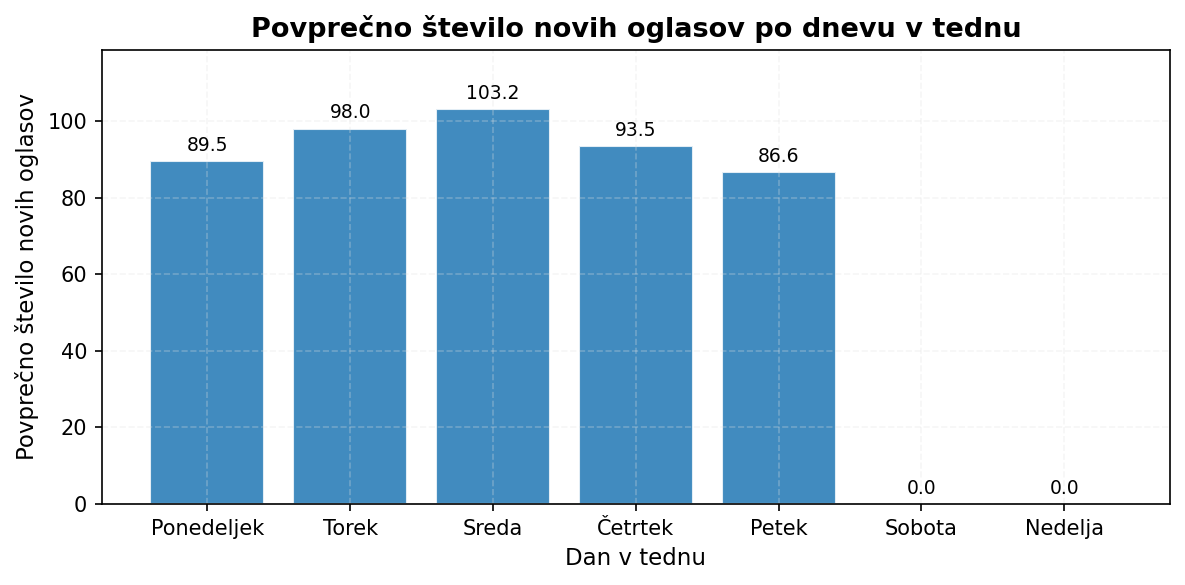

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(
    avg_by_day.index,
    avg_by_day["Povprečje novih oglasov"],
    color=COLORS[0],
    edgecolor="white",
    alpha=0.85,
)
ax.bar_label(bars, labels=[f"{v:.1f}" for v in avg_by_day["Povprečje novih oglasov"]], padding=3, fontsize=9)

ax.set_xlabel("Dan v tednu")
ax.set_ylabel("Povprečno število novih oglasov")
ax.set_title("Povprečno število novih oglasov po dnevu v tednu")
ax.set_ylim(top=avg_by_day["Povprečje novih oglasov"].max() * 1.15)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Ugotovitve
- Za zapis ugotovitev moramo počakati do vsaj konca aprila, da bomo imeli zadosti rezultatov.
- Pomembno je omeniti, da določimo dan novih oglasov na podlagi `first_seen`. Z eno soboto (14.3.2026) je problem, ker smo pognali scarper v soboto, pobral pa je nove oglase za petek, ker scraper ni bil pognan v petek. Ker imamo sedaj scarper avtomatiziran, ne bo prišlo več do teh težav. Razultat ~~bomo~~ smo mogli malce prirediti, tako da ~~bomo~~ smo za to eno soboto dodali razlutate v petek.
---
- Kateri dnevi v tednu imajo največ novih oglasov?
- Ali se hipoteza potrdi, da je med tednom (pon–pet) več novih oglasov kot ob vikendih?
- Katere dni bi študentom priporočili, da redno preverjajo portal?
- Omejitev: vzorec zajema relativno kratko obdobje, zato rezultati morda niso popolnoma posplošljivi.

## Vprašanje 6: Ali dela z manj prostimi mesti ponujajo višjo plačo?

### Opis
Raziskujemo, ali obstaja povezava med številom prostih mest (`open_positions`) in povprečno neto urno postavko (`hourly_rate_neto`). Ali dela, ki imajo manj razpoložljivih delovnih mest, plačujejo več — ker so morda bolj specializirana ali zahtevna?

Filtriramo na oglase z urnim tipom plačila (`HOURLY`). Oglase razdelimo v intervale glede na število prostih mest. Kjer stolpec `open_positions` ni izpolnjen, predpostavimo 1 prosto mesto — to je smiselno, saj je najnižja eksplicitna vrednost v podatkih 2.

**Hipoteza:** Dela z manj prostimi mesti ponujajo višjo povprečno plačo.

### Analiza

In [23]:
# Filtriramo na urni tip plačila z znano plačo
df_v6 = data[
    (data["normalized_payment_type"] == "HOURLY")
    & data["hourly_rate_neto"].notna()
    ].copy()

# Kjer open_positions ni izpolnjen, predpostavimo 1 prosto mesto
df_v6["open_positions"] = df_v6["open_positions"].fillna(1)

# Intervali prostih mest
bins = [0, 1, 2, 4, 9, float("inf")]
labels = ["1", "2", "3–4", "5–9", "10+"]
df_v6["interval"] = pd.cut(df_v6["open_positions"], bins=bins, labels=labels, right=True)

# Povprečje, mediana in število oglasov po intervalu
pay_by_positions = df_v6.groupby("interval", observed=False)["hourly_rate_neto"].agg(
    ["mean", "median", "count"]
).rename(columns={"mean": "Povprečje (€)", "median": "Mediana (€)", "count": "Št. oglasov"})
pay_by_positions["Povprečje (€)"] = pay_by_positions["Povprečje (€)"].round(2)
pay_by_positions["Mediana (€)"] = pay_by_positions["Mediana (€)"].round(2)
pay_by_positions.index.name = "Prosta mesta"

display(Markdown(f"**Število vključenih oglasov:** {len(df_v6)}"))
display(pay_by_positions)

**Število vključenih oglasov:** 4120

,Povprečje (€),Mediana (€),Št. oglasov
Prosta mesta,,,
1,8.62,8.00,2193
2,8.63,8.00,1013
3–4,8.71,8.17,584
5–9,9.42,8.17,231
10+,8.93,8.17,99


### Vizualizacija

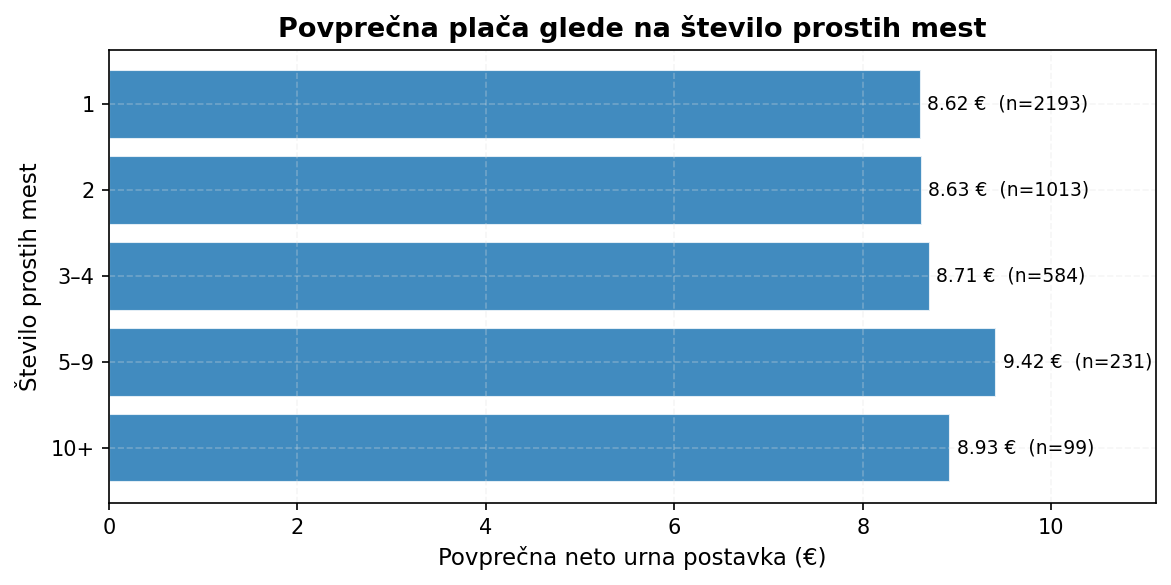

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(
    pay_by_positions.index,
    pay_by_positions["Povprečje (€)"],
    color=COLORS[0],
    edgecolor="white",
    alpha=0.85,
)
ax.bar_label(
    bars,
    labels=[f"{v:.2f} €  (n={n})" for v, n in zip(pay_by_positions["Povprečje (€)"], pay_by_positions["Št. oglasov"])],
    padding=3,
    fontsize=9,
)

ax.set_ylabel("Število prostih mest")
ax.set_xlabel("Povprečna neto urna postavka (€)")
ax.set_title("Povprečna plača glede na število prostih mest")
ax.set_xlim(right=pay_by_positions["Povprečje (€)"].max() * 1.18)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Ugotovitve
- Ali dela z manj prostimi mesti res ponujajo višjo plačo?
- Kako velika je razlika med intervali?
- Ali je vzorec dovolj velik v vseh intervalih za zanesljive zaključke?
- Predpostavka: oglasi brez izpolnjenega `open_positions` imajo 1 prosto mesto (najnižja eksplicitna vrednost je 2).

## Vprašanje 7: Ali se “hitro zapolnjena” dela razlikujejo po plači?

### Opis
Analiziramo, ali oglasi, ki ostanejo krajši čas aktivni na portalu (razlika med `last_seen` in `first_seen`), ponujajo višje ali nižje plačilo.

Cilj je preveriti, ali se bolje plačana dela hitreje zapolnijo in posledično hitreje izginejo iz sistema.

Omejitev: Uporabljamo samo oglase z urnim plačilom, saj omogočajo primerljivo analizo med oglasi.

### Hipoteza
Oglasi z višjo urno postavko se zapolnijo hitreje (imajo krajše trajanje).

#### TODO (pomembno za interpretacijo)
Ugotovitve je treba posodobiti, ko bo scraper deloval dalj časa.
Trenutno je veliko oglasov še vedno aktivnih (še niso zaključeni), kar pomeni, da je izračun trajanja delno podcenjen.
Zato trenutno ne moremo popolnoma zanesljivo sklepati o “hitrosti zapolnitve”, ampak le o približnem odnosu med plačo in trajanjem oglasa.

### Analiza

In [25]:
# filtriramo samo oglase z urno postavko
hourly_ads = data[data["hourly_rate_neto"].notna()].copy()

# trajanje oglasa v dnevih
hourly_ads["ad_duration_days"] = (
        hourly_ads["last_seen"] - hourly_ads["first_seen"]
).dt.days

# odstrani napačne vrednosti
hourly_ads = hourly_ads[hourly_ads["ad_duration_days"] >= 0]

stats = pd.DataFrame({
    "Metrika": [
        "Število oglasov z urno postavko",
        "Povprečna plača (€)",
        "Povprečno trajanje (št. dni)",
        "Min trajanje oglasa",
        "Max trajanje oglasa"
    ],
    "Vrednost": [
        len(hourly_ads),
        hourly_ads["hourly_rate_neto"].mean().round(2),
        hourly_ads["ad_duration_days"].mean().round(2),
        hourly_ads["ad_duration_days"].min(),
        hourly_ads["ad_duration_days"].max()
    ]
})

correlation = hourly_ads["hourly_rate_neto"].corr(hourly_ads["ad_duration_days"])

#formatiran izpis za lažjo berljivost
display(
    stats.style
    .hide(axis="index")
    .format({"Vrednost": "{:.2f}"}, na_rep="—")
)
display(Markdown(f"""
Pearsonova korelacija med `hourly_rate_neto` in `ad_duration_days` je: {correlation:.3f}**
"""))

Metrika,Vrednost
Število oglasov z urno postavko,4120.00
Povprečna plača (€),8.69
Povprečno trajanje (št. dni),15.46
Min trajanje oglasa,0.00
Max trajanje oglasa,28.00



Pearsonova korelacija med `hourly_rate_neto` in `ad_duration_days` je: -0.027**


### Vizualizacija

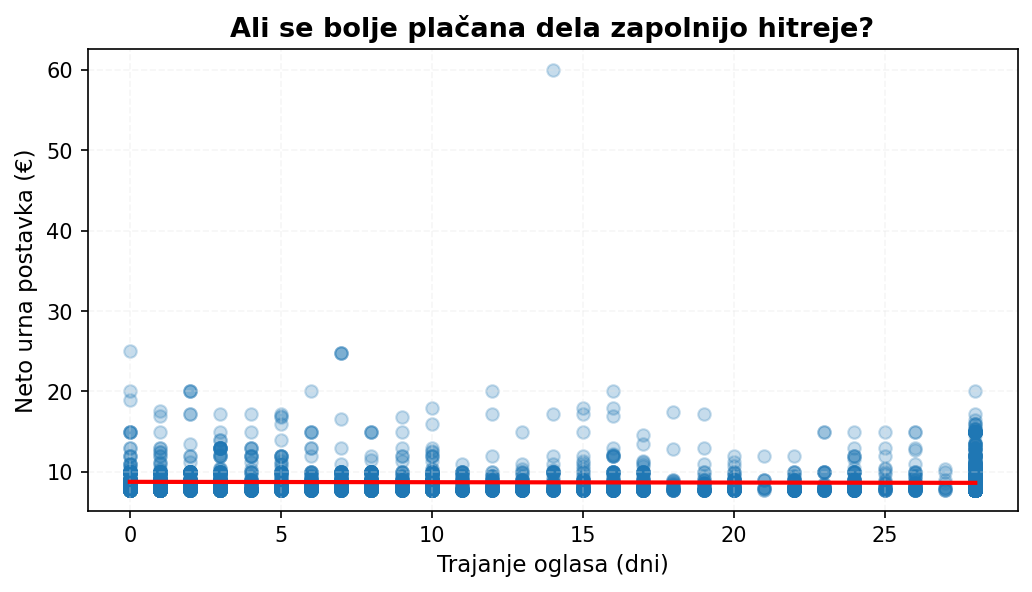

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.scatter(
    hourly_ads["ad_duration_days"],
    hourly_ads["hourly_rate_neto"],
    alpha=0.25,
    color=COLORS[0]
)

# trend linija
z = np.polyfit(hourly_ads["ad_duration_days"], hourly_ads["hourly_rate_neto"], 1)
p = np.poly1d(z)

x_line = np.linspace(
    hourly_ads["ad_duration_days"].min(),
    hourly_ads["ad_duration_days"].max(),
    100
)

ax.plot(x_line, p(x_line), color="red", linewidth=2)

ax.set_xlabel("Trajanje oglasa (dni)")
ax.set_ylabel("Neto urna postavka (€)")
ax.set_title("Ali se bolje plačana dela zapolnijo hitreje?")

plt.show()

In [27]:
display(Markdown(f"""
### Ugotovitve

- V podatkih ni opazne povezave med višino urne postavke in trajanjem oglasa.
- Korelacija je približno **{correlation:.3f}**, kar pomeni, da ni opazne linearne povezave med plačo in trajanjem oglasa.
- Trendna linija na grafu je skoraj ravna, kar dodatno potrjuje odsotnost linearnega trenda.

Na podlagi podatkov ne moremo trditi, da višja plača pomeni hitrejšo zapolnitev oglasa.
"""))


### Ugotovitve

- V podatkih ni opazne povezave med višino urne postavke in trajanjem oglasa.
- Korelacija je približno **-0.027**, kar pomeni, da ni opazne linearne povezave med plačo in trajanjem oglasa.
- Trendna linija na grafu je skoraj ravna, kar dodatno potrjuje odsotnost linearnega trenda.

Na podlagi podatkov ne moremo trditi, da višja plača pomeni hitrejšo zapolnitev oglasa.


## Vprašanje 8: Kdo obvladuje trg študentskega dela? Koncentracija oglasov med podjetji

### Opis
Analiziramo, kako so študentski oglasi porazdeljeni med podjetja.

Zanima nas, ali trg študentskega dela obvladuje nekaj velikih delodajalcev ali pa je bolj razpršen med veliko manjših podjetij.

Za analizo uporabimo Pareto princip in porazdelitev oglasov po podjetjih.

#### Opis pareto principa
Pareto princip (80/20 pravilo) pravi, da približno 20 % vzrokov pogosto ustvari 80 % posledic.
V kontekstu naše analize to pomeni, da preverjamo, ali majhno število podjetij ustvari večino oglasov na platformi.

#### Opis long-tail analize
Long-tail analiza opisuje porazdelitev, kjer majhno število enot prispeva velik del aktivnosti, medtem ko velika večina enot prispeva le majhen del.
V našem primeru to pomeni, da majhno število podjetij ustvari velik delež oglasov, medtem ko ima veliko podjetij le enega ali nekaj oglasov.

Cilj je ugotoviti:
- ali majhno število podjetij generira večino oglasov
- kako močna je koncentracija trga
- ali obstaja dolg “rep” manjših delodajalcev

### Hipoteza
Majhno število podjetij generira večino oglasov na platformi (Pareto princip približno velja), medtem ko večina podjetij prispeva le majhen delež oglasov.


### Analiza

In [28]:
# Število oglasov po podjetjih
company_counts = data["company"].value_counts()

total_ads = len(data)

# Koncentracija trga
top_1_share = (company_counts.head(1).sum() / total_ads) * 100
top_5_share = (company_counts.head(5).sum() / total_ads) * 100
top_10_share = (company_counts.head(10).sum() / total_ads) * 100

# Long tail analiza
one_ad_companies = (company_counts == 1).sum()
small_activity_companies = ((company_counts >= 2) & (company_counts <= 5)).sum()
high_activity_companies = (company_counts >= 6).sum()

summary = pd.DataFrame({
    "Opis": [
        "Število podjetij na platformi",
        "Delež oglasov največjega podjetja",
        "Delež oglasov top 5 podjetij",
        "Delež oglasov top 10 podjetij",
        "Podjetja z 1 oglasom",
        "Podjetja z 2–5 oglasi",
        "Podjetja z 6+ oglasi"
    ],
    "Vrednost": [
        len(company_counts),
        f"{round(top_1_share, 2)}%",
        f"{round(top_5_share, 2)}%",
        f"{round(top_10_share, 2)}%",
        one_ad_companies,
        small_activity_companies,
        high_activity_companies
    ]
})

display(summary)

,Opis,Vrednost
0,Število podjetij na platformi,2579
1,Delež oglasov največjega podjetja,4.25%
2,Delež oglasov top 5 podjetij,9.41%
3,Delež oglasov top 10 podjetij,11.69%
4,Podjetja z 1 oglasom,1880
5,Podjetja z 2–5 oglasi,637
6,Podjetja z 6+ oglasi,62


### Vizualizacija

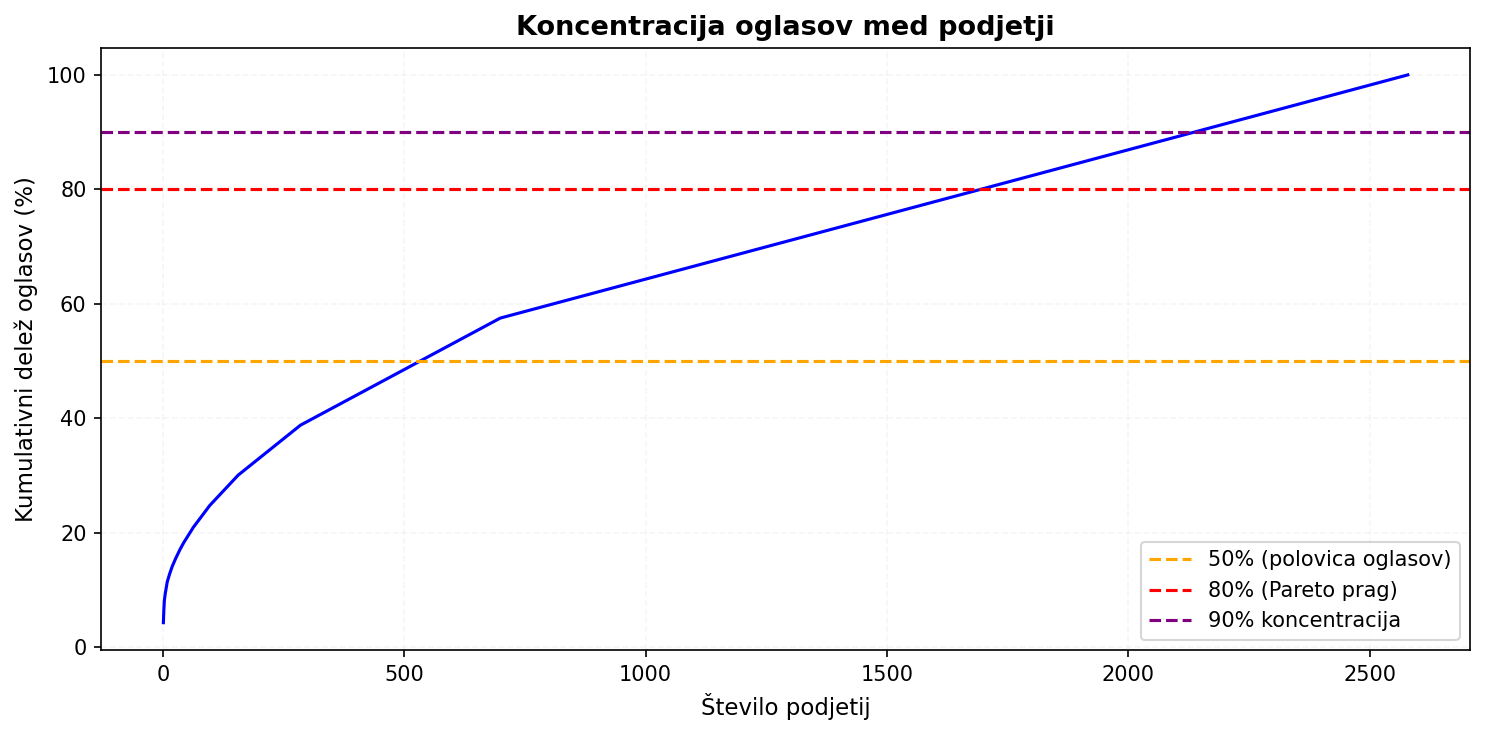

In [29]:
sorted_counts = company_counts.sort_values(ascending=False)
cum_share = sorted_counts.cumsum() / sorted_counts.sum() * 100

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(range(1, len(cum_share) + 1), cum_share.values, color="blue")

ax.set_title("Koncentracija oglasov med podjetji")
ax.set_xlabel("Število podjetij")
ax.set_ylabel("Kumulativni delež oglasov (%)")

ax.axhline(50, color="orange", linestyle="--", label="50% (polovica oglasov)")
ax.axhline(80, color="red", linestyle="--", label="80% (Pareto prag)")
ax.axhline(90, color="purple", linestyle="--", label="90% koncentracija")
ax.legend()

plt.tight_layout()
plt.show()

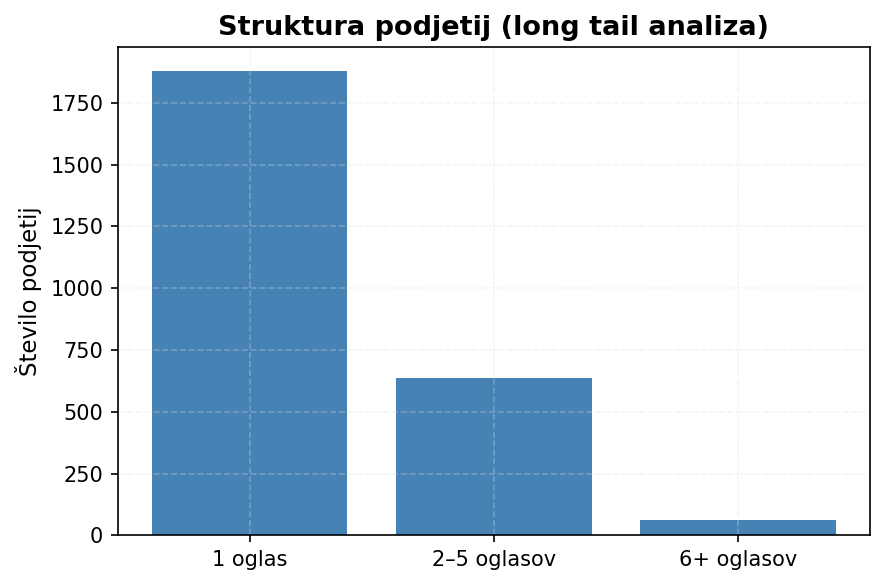

In [30]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    ["1 oglas", "2–5 oglasov", "6+ oglasov"],
    [one_ad_companies, small_activity_companies, high_activity_companies],
    color="steelblue"
)

ax.set_title("Struktura podjetij (long tail analiza)")
ax.set_ylabel("Število podjetij")

plt.tight_layout()
plt.show()

In [31]:
company_counts = data["company"].value_counts().dropna()

total_ads = company_counts.sum()
total_companies = len(company_counts)

sorted_counts = company_counts.sort_values(ascending=False)

# osnovni deleži
top_1_share = sorted_counts.iloc[0] / total_ads * 100
top_5_share = sorted_counts.head(5).sum() / total_ads * 100
top_10_share = sorted_counts.head(10).sum() / total_ads * 100

# long tail struktura
one_ad = (company_counts == 1).sum()
two_to_five = ((company_counts >= 2) & (company_counts <= 5)).sum()
six_plus = (company_counts >= 6).sum()

display(Markdown(f"""
### Ugotovitve

Trg je na prvi pogled precej razpršen, saj največje podjetje predstavlja le **{top_1_share:.2f}%** vseh oglasov.

Delež {top_1_share:.2f}% za največje podjetje ni ne posebej visok ne zanemarljiv. V absolutnem smislu pomeni približno {sorted_counts.iloc[0]} oglasov, kar kaže, da ima podjetje opazno prisotnost, vendar ne dominira trga.

Top 5 podjetij skupaj predstavlja **{top_5_share:.2f}%**, top 10 podjetij pa **{top_10_share:.2f}%** vseh oglasov.

To pomeni, da ni ekstremne monopolne dominance, saj noben posamezen "super-delodajalec" ne obvladuje večine trga.

Rezultat pokaže, da za 80% vseh oglasov potrebujemo bistveno več kot 20% podjetij, kar pomeni, da klasičen Pareto princip (80/20) v naših podatkih ne velja.

Zato lahko zaključimo, da je trg bolj razpršen, kot predvideva Pareto pravilo, čeprav še vedno obstaja določena koncentracija aktivnosti pri manjšem številu podjetij.

### Struktura podjetij

- {one_ad} podjetij (≈ {(one_ad / total_companies) * 100:.1f}%) ima samo 1 oglas
- {two_to_five} podjetij ima 2–5 oglasov  
- {six_plus} podjetij ima 6 ali več oglasov  


### Interpretacija (long-tail struktura)

Podatki jasno kažejo tipično long-tail porazdelitev:
veliko število majhnih ali občasnih delodajalcev in majhno število podjetij, ki generirajo večji delež oglasov.
"""))


### Ugotovitve

Trg je na prvi pogled precej razpršen, saj največje podjetje predstavlja le **4.25%** vseh oglasov.

Delež 4.25% za največje podjetje ni ne posebej visok ne zanemarljiv. V absolutnem smislu pomeni približno 188 oglasov, kar kaže, da ima podjetje opazno prisotnost, vendar ne dominira trga.

Top 5 podjetij skupaj predstavlja **9.41%**, top 10 podjetij pa **11.69%** vseh oglasov.

To pomeni, da ni ekstremne monopolne dominance, saj noben posamezen "super-delodajalec" ne obvladuje večine trga.

Rezultat pokaže, da za 80% vseh oglasov potrebujemo bistveno več kot 20% podjetij, kar pomeni, da klasičen Pareto princip (80/20) v naših podatkih ne velja.

Zato lahko zaključimo, da je trg bolj razpršen, kot predvideva Pareto pravilo, čeprav še vedno obstaja določena koncentracija aktivnosti pri manjšem številu podjetij.

### Struktura podjetij

- 1880 podjetij (≈ 72.9%) ima samo 1 oglas
- 637 podjetij ima 2–5 oglasov  
- 62 podjetij ima 6 ali več oglasov  


### Interpretacija (long-tail struktura)

Podatki jasno kažejo tipično long-tail porazdelitev:
veliko število majhnih ali občasnih delodajalcev in majhno število podjetij, ki generirajo večji delež oglasov.


## Vprašanje 9: Katere vrste atributov so najbolje plačane?

### Opis


V tem delu analiziramo, kako se `hourly_rate_neto` razlikuje glede na različne atribute( kot so `work_schedule`, `trajanje`, `normalized_city`, `normalized_region` in `category`)

Zavedamo se, da se število oglasov lahko razlikuje gledena vrednost atributa, zato smo se odločili, da bomo filtrirali gledena **min_count**.

Uporabljamo mediano za min_count, saj je manj občutljiva na razlike med višjimi vrednostmi. 

To nam bo pomagalo zmanjšati vpliv šuma nad našimi podatki.

Za analizo bomo uporabili ta povprečno plačo kot tudi mediano, saj bomo tako lahko izvedeli ali se v podatkih nahaja veliko ekstremnih ponudb, ki niso skladne z "normalnimi" ponudbami. 

Če se pa povprečje in mediana ujemata, to običajno pomeni, da v podatkih ni izrazitih ekstremnih vrednosti in da je porazdelitev relativno simetrična. Vendar pa to ni popolno zagotovilo, saj lahko manjši outlierji še vedno obstajajo, vendar nimajo velikega vpliva na povprečje. 

### Hipoteza:

Pričakujemo, da obstajajo opazne razlike v plačilu glede na lastnosti atributa.

## Analiza

In [32]:
def avg_salary_by(df, column, min_count):
    """
    Izračuna povprečno plačo glede na izbran atribut.
    
    column = ime stolpca (npr. 'company', 'work_schedule', ...)
    min_count = minimalno število oglasov (da odstraniš šum)
    """

    # filtriraj vrstice brez plače
    data = df[df['hourly_rate_neto'].notna()]

    # groupby + statistika
    stats = data.groupby(column)['hourly_rate_neto'].agg(["median", "mean", "count"]).rename(
        columns={"median": "Mediana (€)", "mean": "Povprečje (€)", "count": "Št. oglasov"})

    # odstrani nepomembne (premalo podatkov)
    stats = stats[stats["Št. oglasov"] >= min_count]

    # sortiraj
    stats = stats.sort_values(by='Povprečje (€)', ascending=False)

    #razlika med mediano in povprečno plačo
    stats["Razlika (€)"] = stats["Povprečje (€)"] - stats["Mediana (€)"]

    stats = stats[stats["Št. oglasov"] >= min_count]
    stats = stats.sort_values(by='Povprečje (€)', ascending=False)

    return stats


def categorize(title):
    title = title.upper()

    # IT
    if "PROGRAM" in title or "IT" in title or "DEVELOPER" in title or "RAČUNAL" in title:
        return "IT"

    # ZDRAVSTVO
    elif "ZDRAV" in title or "MEDIC" in title or "NEGA" in title or "BOLNIŠ" in title:
        return "ZDRAVSTVO"

    # TEHNIKA / INŽENIRSTVO
    elif "INŽENIR" in title or "TEHNIK" in title or "ELEKTRO" in title or "STROJN" in title or "MEHANIK" in title or "VZDRŽEVAN" in title:
        return "TEHNIKA / INŽENIRSTVO"

    # TEREN / RAZVOZ
    elif "TEREN" in title or "DOSTAV" in title or "RAZVOZ" in title or "VOZNIK" in title or "KURIR" in title:
        return "TEREN / RAZVOZ"

    # GOSTINSTVO
    elif "STREŽ" in title or "KUHINJ" in title or "NATAKAR" in title:
        return "GOSTINSTVO"

    # PRODAJA
    elif "TRGOV" in title or "PRODAJA" in title or "BLAGAJN" in title:
        return "PRODAJA"

    # ADMINISTRACIJA
    elif "ADMIN" in title or "PISARN" in title:
        return "ADMINISTRACIJA"

    # PROIZVODNJA
    elif "PROIZVODN" in title:
        return "PROIZVODNJA"

    # SKLADIŠČE / LOGISTIKA
    elif "SKLADIŠ" in title or "PAKIRAN" in title or "PICKER" in title:
        return "SKLADIŠČE"

    # FIZIČNO DELO
    elif "FIZIČ" in title or "TEREN" in title:
        return "FIZIČNO DELO"

    # PROMOCIJA
    elif "PROMOCI" in title or "PROMOTOR" in title or "HOSTES" in title:
        return "PROMOCIJA"

    # ČIŠČENJE
    elif "ČIŠČ" in title or "ČISTIL" in title:
        return "ČIŠČENJE"

    # VARSTVO
    elif "VARSTV" in title or "OTROK" in title:
        return "VARSTVO"

    # PODPORA / KLICNI CENTER
    elif "PODPORA" in title or "SUPPORT" in title or "KLICNI CENTER" in title or "CUSTOMER" in title:
        return "PODPORA / KLICNI CENTER"

    # POUČEVANJE
    elif "UČIT" in title or "PROFES" in title or "INŠTRUK" in title or "TUTOR" in title or "PEDAGOG" in title or "VZGOJIT" in title or "POUČEVANJE" in title:
        return "POUČEVANJE"

    else:
        return "OSTALO"


data["category"] = titles.map(categorize)


# Lepši prikaz tabele
def show_table(df):
    display(
        df.style
        .format({
            "Povprečje (€)": "{:.2f} €",
            "Mediana (€)": "{:.2f} €",
            "Št. oglasov": "{:d}"
        })
        .background_gradient(subset=["Povprečje (€)"], cmap="YlGn")
        .background_gradient(subset=["Mediana (€)"], cmap="YlGn")
    )


# FUNKCIJA ZA IZPIS (DRY PRINCIP)

def izpis_za_atribut(df, column, min_count=0, sort_by="Povprečje (€)"):
    print("\n-------------------------------------------------------")
    print(column.upper())
    print("-------------------------------------------------------")

    stats = avg_salary_by(df, column, min_count)
    stats = stats.sort_values(by=sort_by, ascending=False)

    show_table(stats)

    return stats


data_work_schedule = izpis_za_atribut(data, 'work_schedule')
data_trajanje = izpis_za_atribut(data, 'trajanje')

data_city = avg_salary_by(data, 'normalized_city', 10)
data_city = izpis_za_atribut(data, 'normalized_city', min_count=data_city['Št. oglasov'].median(),
                             sort_by='Povprečje (€)')
display(data_city['Št. oglasov'].median())

data_region = izpis_za_atribut(data, 'normalized_region')
data_category = izpis_za_atribut(data, 'category')


-------------------------------------------------------
WORK_SCHEDULE
-------------------------------------------------------


,Mediana (€),Povprečje (€),Št. oglasov,Razlika (€)
work_schedule,,,,
POPOLDAN,8.17 €,9.03 €,313,0.855463
PO DOGOVORU,8.17 €,9.00 €,1357,0.834392
DOPOLDAN,8.00 €,8.64 €,1092,0.641593
MED VIKENDI,8.15 €,8.55 €,142,0.395423
IZMENSKO,8.00 €,8.30 €,1216,0.302961



-------------------------------------------------------
TRAJANJE
-------------------------------------------------------


,Mediana (€),Povprečje (€),Št. oglasov,Razlika (€)
trajanje,,,,
OSTALO,8.61 €,9.18 €,250,0.572920
PO DOGOVORU,8.00 €,8.85 €,1090,0.854807
DLJE ČASA,8.00 €,8.58 €,2780,0.576594



-------------------------------------------------------
NORMALIZED_CITY
-------------------------------------------------------


...

np.float64(41.0)


-------------------------------------------------------
NORMALIZED_REGION
-------------------------------------------------------


,Mediana (€),Povprečje (€),Št. oglasov,Razlika (€)
normalized_region,,,,
GORENJSKA,8.10 €,8.80 €,449,0.701247
GORIŠKA,8.09 €,8.80 €,84,0.715000
OSREDNJESLOVENSKA,8.15 €,8.79 €,1788,0.638249
SAVINJSKA,8.00 €,8.59 €,355,0.593690
OBALNO-KRAŠKA,8.00 €,8.55 €,312,0.554679
KOROŠKA,7.74 €,8.53 €,49,0.791224
JUGOVZHODNA SLOVENIJA,8.00 €,8.46 €,224,0.462813
POMURSKA,8.00 €,8.45 €,84,0.451667
PRIMORSKO-NOTRANJSKA,8.00 €,8.43 €,62,0.432097



-------------------------------------------------------
CATEGORY
-------------------------------------------------------


,Mediana (€),Povprečje (€),Št. oglasov,Razlika (€)
category,,,,
POUČEVANJE,12.00 €,11.90 €,97,-0.104742
PROMOCIJA,9.54 €,10.03 €,130,0.491308
VARSTVO,8.20 €,9.65 €,35,1.450286
IT,8.61 €,9.44 €,328,0.829512
FIZIČNO DELO,8.61 €,8.91 €,78,0.303077
OSTALO,8.00 €,8.86 €,794,0.860705
ZDRAVSTVO,8.50 €,8.75 €,111,0.245946
TEREN / RAZVOZ,8.00 €,8.66 €,155,0.656452
PODPORA / KLICNI CENTER,8.00 €,8.51 €,39,0.507179


## Vizualizacija

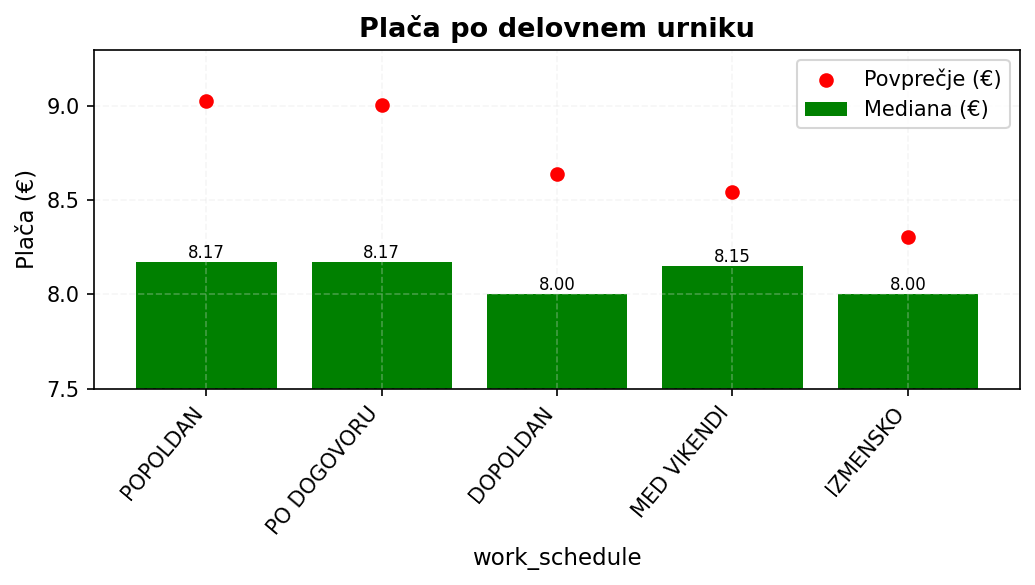

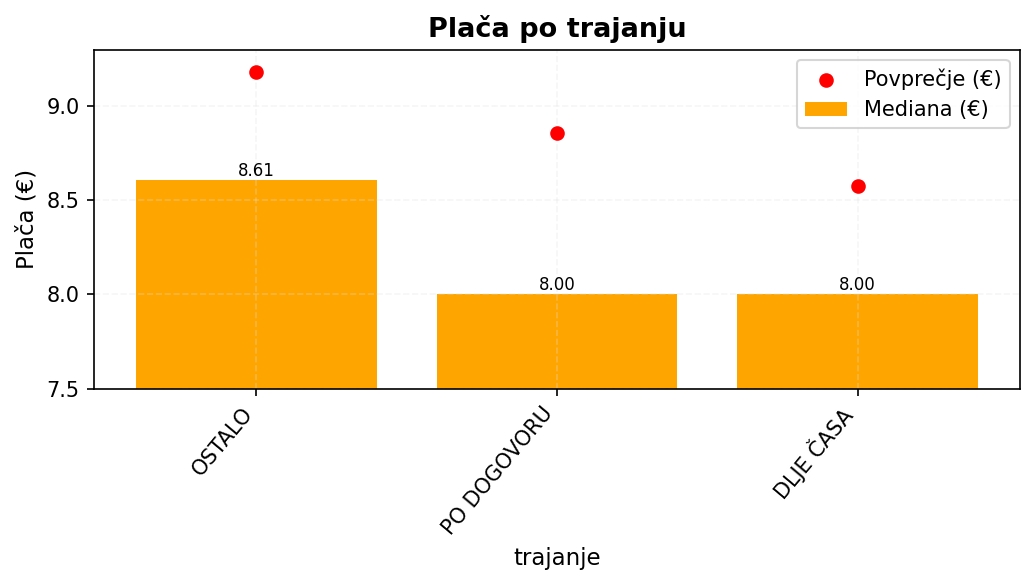

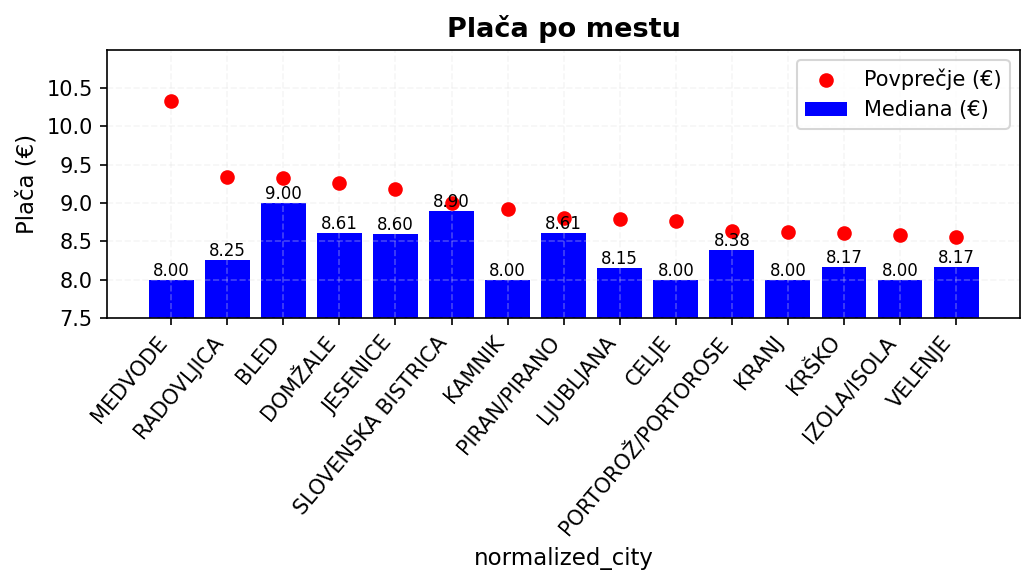

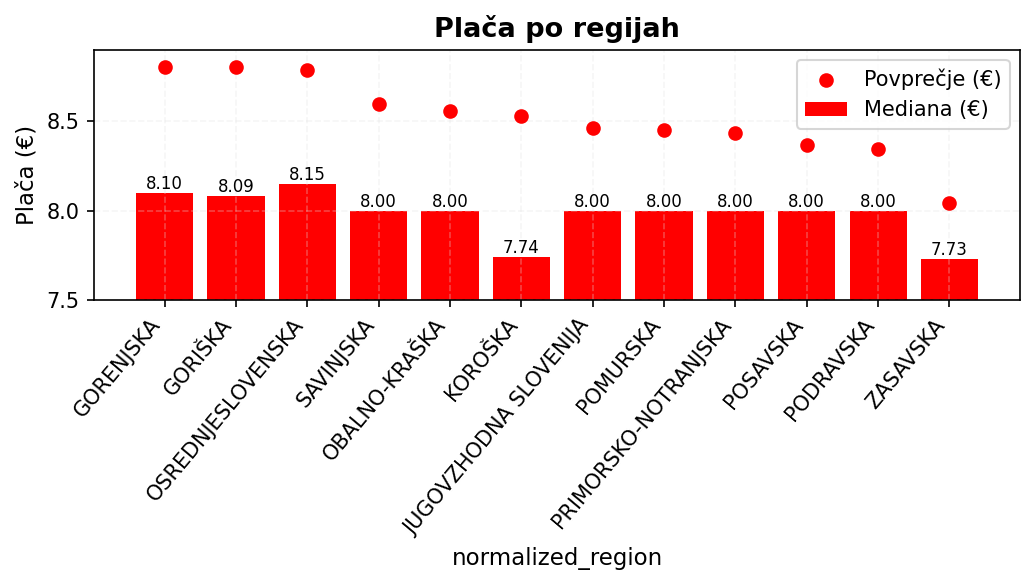

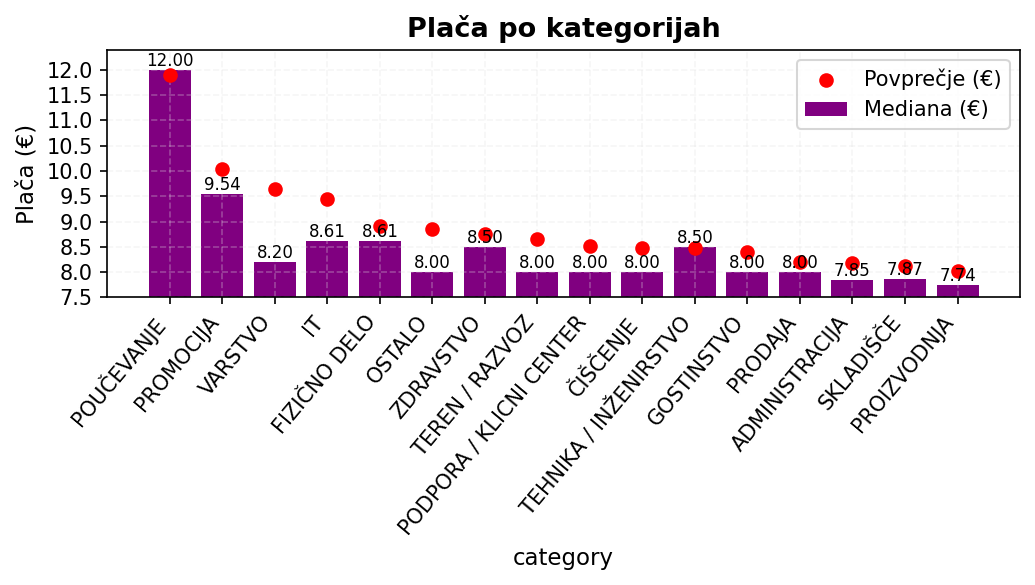

In [33]:
def plot_bar(df, column, title, min_count=0, top_n=None, od=0, do=0, color="black"):
    stats = avg_salary_by(df, column, min_count)

    if top_n:
        stats = stats.head(top_n)

    plt.figure()

    # modri stolpci = MEDIANA
    bars = plt.bar(
        stats.index.astype(str),
        stats["Mediana (€)"],
        color=color,
        label="Mediana (€)"
    )

    # rdeče točke = POVPREČJE
    plt.scatter(
        stats.index.astype(str),
        stats["Povprečje (€)"],
        color="red",
        label="Povprečje (€)",
        zorder=3
    )

    plt.title(title)
    plt.ylabel("Plača (€)")
    plt.xlabel(column)

    plt.ylim(od, do)
    plt.yticks(np.arange(od, do, 0.5))

    plt.xticks(rotation=50, ha='right')

    # vrednosti nad stolpci (mediana)
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.2f}",
            ha='center',
            va='bottom',
            fontsize=8
        )

    # legenda
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_bar(data, 'work_schedule', "Plača po delovnem urniku", od=7.5, do=9.3, color="green")
plot_bar(data, 'trajanje', "Plača po trajanju", od=7.5, do=9.3, color="orange")

data_city = avg_salary_by(data, 'normalized_city', 10)
plot_bar(data, 'normalized_city', "Plača po mestu", min_count=data_city['Št. oglasov'].median(), top_n=15, od=7.5,
         do=11.0, color="blue")
plot_bar(data, 'normalized_region', "Plača po regijah", od=7.5, do=8.9, color="red")

plot_bar(data, 'category', "Plača po kategorijah", od=7.5, do=12.4, color="purple")


## Ugotovitev

### Ugotovitve

- Plače se med kategorijami opazno razlikujejo, pri čemer so najnižje v fizičnih in storitvenih dejavnostih.
- Regije kažejo manjše razlike kot kategorije, kar pomeni, da ima vrsta dela večji vpliv kot lokacija.
- Poučevanje je najbolje plačano.
- Vidimo da je pri vseh atributih, povprečna plača za vsaj 50centov višja koker mediana. Lahko sklepamo da se pri vseh atributih nahajajo oglasi ki ponujajo veliko več koker drugi.
### Omejitve
- ne upoštevamo drugih dejavnikov (izkušnje, podjetje)

## Vprašanje 10: Katere vrste dela so najbolj iskane v določenih regijah?

### Opis

Zanima nas kakšne vrste dela so najbolj iskane v regijah po Sloveniji. Vredno je vedeti, v katerih regijah se išče katero vrsto dela bolj pogosto, saj tako lahko damo prioriteto oglasom, ki se pojavijo redkeje v določeni regiji (ali zaradi bližine, plače, itd.).
Za analizo, bomo uporabili:
- `normalized_region`, da bomo pridobili regije
- `category`, da dobimo kategorije

Cilj je da ugotovimo:
- kje se nahajajo dela najbolj pogosto, ki nas zanimajo; 
- katere vrste dela, so najbolj iskane v naši okolici
- ali lokacija vpliva na deleže
- 
Naredili bomo matriko in izračunali delež, ki ga ta vrsta zaseda.

### Analiza

In [34]:
# count matrika
matrix = data.pivot_table(
    index='normalized_region',
    columns='category',
    aggfunc='size',
    fill_value=0
)

# pretvorba v deleže
matrix_pct = matrix.div(matrix.sum(axis=1), axis=0)

# reshape v long format za plotly
df_plot = matrix_pct.reset_index().melt(
    id_vars='normalized_region',
    var_name='Category',
    value_name='Share'
)
display(matrix)
display(matrix_pct)

category,ADMINISTRACIJA,FIZIČNO DELO,GOSTINSTVO,IT,OSTALO,PODPORA / KLICNI CENTER,POUČEVANJE,PRODAJA,PROIZVODNJA,PROMOCIJA,SKLADIŠČE,TEHNIKA / INŽENIRSTVO,TEREN / RAZVOZ,VARSTVO,ZDRAVSTVO,ČIŠČENJE
normalized_region,,,,,,,,,,,,,,,,
GORENJSKA,10,6,140,26,97,1,16,92,15,11,11,8,17,5,18,8
GORIŠKA,6,1,15,2,28,0,0,22,0,8,0,0,3,0,2,1
JUGOVZHODNA SLOVENIJA,4,7,72,19,43,0,5,38,10,5,10,5,12,2,4,3
KOROŠKA,0,0,15,2,7,0,0,14,1,5,1,2,2,1,2,0
OBALNO-KRAŠKA,9,5,137,13,64,0,3,46,4,19,5,2,10,2,7,7
OSREDNJESLOVENSKA,104,40,491,192,386,30,75,227,47,35,64,53,72,16,62,21
PODRAVSKA,20,5,153,47,89,4,5,46,13,17,13,8,20,2,9,4
POMURSKA,1,2,26,9,24,0,0,14,5,5,0,1,3,1,0,1
POSAVSKA,3,2,43,3,18,1,1,24,6,3,2,4,1,1,3,1


category,ADMINISTRACIJA,FIZIČNO DELO,GOSTINSTVO,IT,OSTALO,PODPORA / KLICNI CENTER,POUČEVANJE,PRODAJA,PROIZVODNJA,PROMOCIJA,SKLADIŠČE,TEHNIKA / INŽENIRSTVO,TEREN / RAZVOZ,VARSTVO,ZDRAVSTVO,ČIŠČENJE
normalized_region,,,,,,,,,,,,,,,,
GORENJSKA,0.020790,0.012474,0.291060,0.054054,0.201663,0.002079,0.033264,0.191268,0.031185,0.022869,0.022869,0.016632,0.035343,0.010395,0.037422,0.016632
GORIŠKA,0.068182,0.011364,0.170455,0.022727,0.318182,0.000000,0.000000,0.250000,0.000000,0.090909,0.000000,0.000000,0.034091,0.000000,0.022727,0.011364
JUGOVZHODNA SLOVENIJA,0.016736,0.029289,0.301255,0.079498,0.179916,0.000000,0.020921,0.158996,0.041841,0.020921,0.041841,0.020921,0.050209,0.008368,0.016736,0.012552
KOROŠKA,0.000000,0.000000,0.288462,0.038462,0.134615,0.000000,0.000000,0.269231,0.019231,0.096154,0.019231,0.038462,0.038462,0.019231,0.038462,0.000000
OBALNO-KRAŠKA,0.027027,0.015015,0.411411,0.039039,0.192192,0.000000,0.009009,0.138138,0.012012,0.057057,0.015015,0.006006,0.030030,0.006006,0.021021,0.021021
OSREDNJESLOVENSKA,0.054308,0.020888,0.256397,0.100261,0.201567,0.015666,0.039164,0.118538,0.024543,0.018277,0.033420,0.027676,0.037598,0.008355,0.032376,0.010966
PODRAVSKA,0.043956,0.010989,0.336264,0.103297,0.195604,0.008791,0.010989,0.101099,0.028571,0.037363,0.028571,0.017582,0.043956,0.004396,0.019780,0.008791
POMURSKA,0.010870,0.021739,0.282609,0.097826,0.260870,0.000000,0.000000,0.152174,0.054348,0.054348,0.000000,0.010870,0.032609,0.010870,0.000000,0.010870
POSAVSKA,0.025862,0.017241,0.370690,0.025862,0.155172,0.008621,0.008621,0.206897,0.051724,0.025862,0.017241,0.034483,0.008621,0.008621,0.025862,0.008621


## Vizualizacija

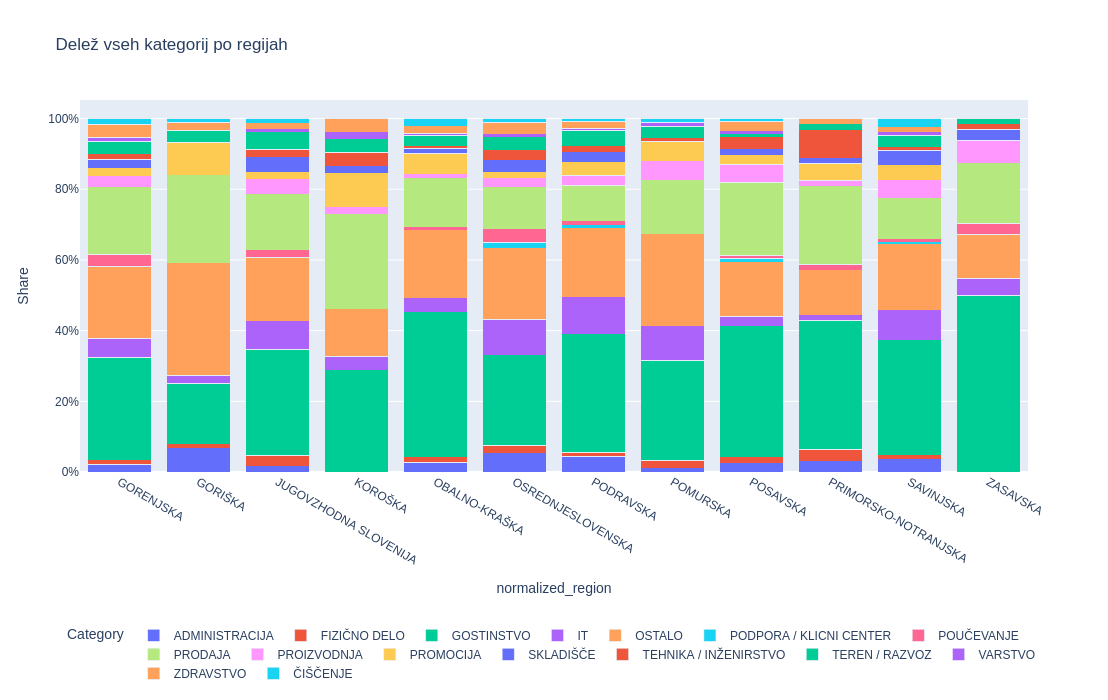

In [35]:
fig = px.bar(
    df_plot,
    x='normalized_region',
    y='Share',
    color='Category',
    barmode='stack',
    title="Delež vseh kategorij po regijah"
)

fig.update_layout(
    width=1100,
    height=700,
    yaxis_tickformat=".0%",
    legend=dict(
        orientation="h",
        y=-0.4,
        x=0.5,
        xanchor="center"
    ),
    margin=dict(b=120)
)

fig.update_traces(
    hovertemplate=
    "<b>%{x}</b><br>" +
    "Kategorija: %{legendgroup}<br>" +
    "Delež: %{y:.2%}<extra></extra>"
)

fig.show()

## Ugotovitev

- Opazimo, da imajo vse regije vsaj po malo zanimanja za vsako kategorijo dela
- največji delež zasede skoraj da vedno GOSTINSTVO, kar je za pričakovati, saj je najbolj iskana kategorija dela

## Vprašanje 11: Katere kombinacije atributov napovedujejo visoko urno postavko?

### Opis

Z metodami strojnega učenja (odločitveno drevo, k-NN, Naivni Bayes) gradimo klasifikacijski model, ki na podlagi atributov oglasa napove, ali bo urna postavka **nizka**, **srednja** ali **visoka**.

Zanima nas:
- Katera kombinacija atributov (vrsta dela, regija, urnik, trajanje) je najboljši napovedovalec visoke postavke?
- Katera metoda deluje bolje in zakaj?
- Ali je mogoče na podlagi vidnih atributov oglasa vnaprej prepoznati "dobro" delo?

**Ciljna spremenljivka:** razred urne postavke, definiran z 33. in 66. percentilom.

In [36]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

### Analiza

#### Priprava podatkov

In [37]:
# Filtriramo samo urne oglase z znano postavko
hourly_cls = data[
    (data["normalized_payment_type"] == "HOURLY") &
    (data["hourly_rate_neto"].notna())
].copy()

# Odstranimo ekstremne outlierje (nad 99. percentilom)
p99 = hourly_cls["hourly_rate_neto"].quantile(0.99)
hourly_cls = hourly_cls[hourly_cls["hourly_rate_neto"] <= p99]

# Meje razredov (33. in 66. percentil)
q33 = hourly_cls["hourly_rate_neto"].quantile(0.33)
q66 = hourly_cls["hourly_rate_neto"].quantile(0.66)

def razred_postavke(x):
    if x < q33:   return "nizka"
    elif x <= q66: return "srednja"
    else:          return "visoka"

hourly_cls["razred"] = hourly_cls["hourly_rate_neto"].apply(razred_postavke)

display(Markdown(f"Meje razredov: **nizka** < {q33:.2f} €, **srednja** {q33:.2f}–{q66:.2f} €, **visoka** > {q66:.2f} €/h"))
display(hourly_cls["razred"].value_counts().rename("Število oglasov").to_frame())
hourly_cls["category"] = titles.map(categorize)
display(hourly_cls["category"])

Meje razredov: **nizka** < 7.80 €, **srednja** 7.80–8.60 €, **visoka** > 8.60 €/h

,Število oglasov
razred,
visoka,1378
srednja,1360
nizka,1341


0                IT
1         ZDRAVSTVO
2        GOSTINSTVO
5        GOSTINSTVO
6        POUČEVANJE
           ...     
4418    PROIZVODNJA
4419       ČIŠČENJE
4420      SKLADIŠČE
4421      SKLADIŠČE
4422         OSTALO
Name: category, Length: 4079, dtype: object

In [38]:
def categorize(title):
    title = title.upper()

    # IT
    if "PROGRAM" in title or "IT" in title or "DEVELOPER" in title or "RAČUNAL" in title:
        return "IT"

    # ZDRAVSTVO
    elif "ZDRAV" in title or "MEDIC" in title or "NEGA" in title or "BOLNIŠ" in title:
        return "ZDRAVSTVO"

    # TEHNIKA / INŽENIRSTVO
    elif "INŽENIR" in title or "TEHNIK" in title or "ELEKTRO" in title or "STROJN" in title or "MEHANIK" in title or "VZDRŽEVAN" in title:
        return "TEHNIKA / INŽENIRSTVO"

    # TEREN / RAZVOZ
    elif "TEREN" in title or "DOSTAV" in title or "RAZVOZ" in title or "VOZNIK" in title or "KURIR" in title:
        return "TEREN / RAZVOZ"

    # GOSTINSTVO
    elif "STREŽ" in title or "KUHINJ" in title or "NATAKAR" in title:
        return "GOSTINSTVO"

    # PRODAJA
    elif "TRGOV" in title or "PRODAJA" in title or "BLAGAJN" in title:
        return "PRODAJA"

    # ADMINISTRACIJA
    elif "ADMIN" in title or "PISARN" in title:
        return "ADMINISTRACIJA"

    # PROIZVODNJA
    elif "PROIZVODN" in title:
        return "PROIZVODNJA"

    # SKLADIŠČE / LOGISTIKA
    elif "SKLADIŠ" in title or "PAKIRAN" in title or "PICKER" in title:
        return "SKLADIŠČE"

    # FIZIČNO DELO
    elif "FIZIČ" in title or "TEREN" in title:
        return "FIZIČNO DELO"

    # PROMOCIJA
    elif "PROMOCI" in title or "PROMOTOR" in title or "HOSTES" in title:
        return "PROMOCIJA"

    # ČIŠČENJE
    elif "ČIŠČ" in title or "ČISTIL" in title:
        return "ČIŠČENJE"

    # VARSTVO
    elif "VARSTV" in title or "OTROK" in title:
        return "VARSTVO"

    # PODPORA / KLICNI CENTER
    elif "PODPORA" in title or "SUPPORT" in title or "KLICNI CENTER" in title or "CUSTOMER" in title:
        return "PODPORA / KLICNI CENTER"

    # POUČEVANJE
    elif "UČIT" in title or "PROFES" in title or "INŠTRUK" in title or "TUTOR" in title or "PEDAGOG" in title or "VZGOJIT" in title or "POUČEVANJE" in title:
        return "POUČEVANJE"

    else:
        return "OSTALO"

def poenostavi_trajanje(d):
    d = str(d).upper()
    if "DLJE" in d or "OBČ" in d: return "DALJ_ČAS"
    elif "SEZON" in d or "POLET" in d or "POČIT" in d: return "SEZONSKO"
    elif "PO DOGOVORU" in d: return "PO_DOGOVORU"
    elif any(x in d for x in ["DAN", "TEDEN", "MESEC"]): return "KRATKO"
    else: return "DOLOČEN_ROK"

hourly_cls["vrsta_dela"] = hourly_cls["title"].apply(categorize)
hourly_cls["regija"]     = hourly_cls["normalized_region"].fillna("NEZNANO")
hourly_cls["urnik"]      = hourly_cls["work_schedule"].fillna("PO DOGOVORU")
hourly_cls["trajanje_cls"] = hourly_cls["duration"].apply(poenostavi_trajanje)

# One-hot encoding + train/test split
features = ["vrsta_dela", "regija", "urnik", "trajanje_cls"]
df_model = hourly_cls[features + ["razred"]].dropna().copy()

X = pd.get_dummies(df_model[features], drop_first=False)
le_cls = LabelEncoder()
y = le_cls.fit_transform(df_model["razred"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)}, Test: {len(X_test)}, Razredi: {le_cls.classes_}")

Train: 3263, Test: 816, Razredi: ['nizka' 'srednja' 'visoka']


#### Odločitveno drevo — optimizacija globine

Optimalna globina: **15** (CV točnost: 0.480)

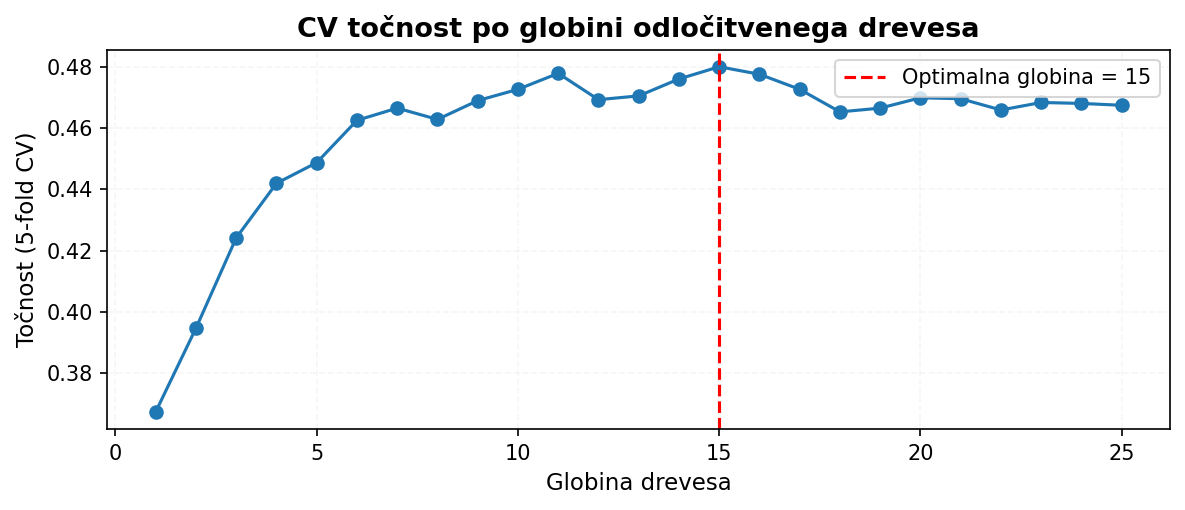

In [39]:
# Cross-validacija po globinah
cv_acc = []
for g in range(1, 26):
    dt = DecisionTreeClassifier(max_depth=g, random_state=42)
    cv_acc.append(cross_val_score(dt, X_train, y_train, cv=5).mean())

best_depth = list(range(1, 26))[int(np.argmax(cv_acc))]
display(Markdown(f"Optimalna globina: **{best_depth}** (CV točnost: {max(cv_acc):.3f})"))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(range(1, 26), cv_acc, "o-", color=COLORS[0])
ax.axvline(best_depth, color="red", linestyle="--", label=f"Optimalna globina = {best_depth}")
ax.set_title("CV točnost po globini odločitvenega drevesa")
ax.set_xlabel("Globina drevesa")
ax.set_ylabel("Točnost (5-fold CV)")
ax.legend()
plt.tight_layout()
plt.show()

#### k-NN — optimizacija k

Optimalni k: **31** (CV točnost: 0.467)

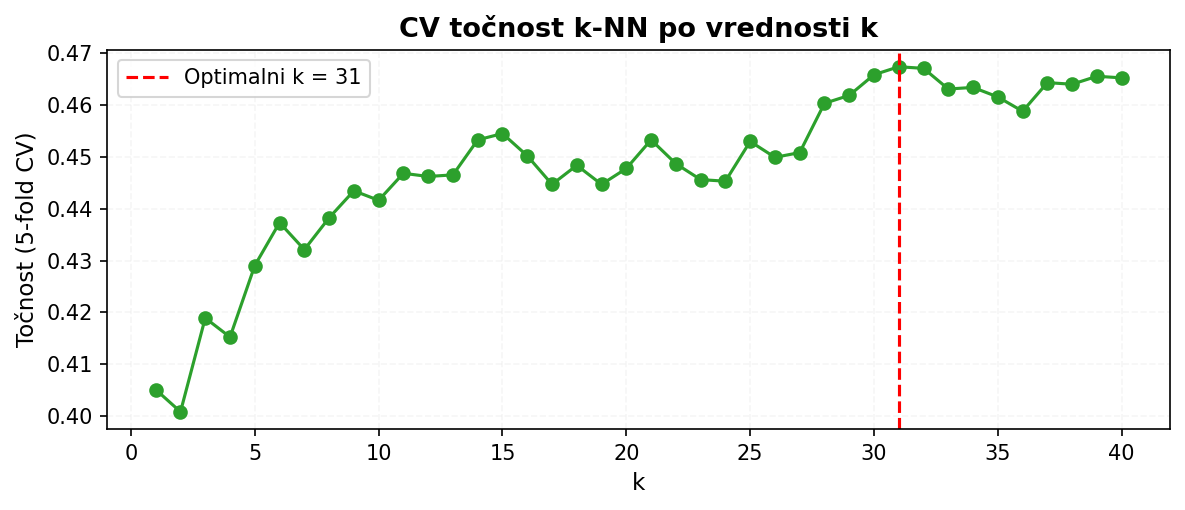

In [40]:
knn_acc = []
for k in range(1, 41):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn_acc.append(cross_val_score(knn, X_train, y_train, cv=5).mean())

best_k = list(range(1, 41))[int(np.argmax(knn_acc))]
display(Markdown(f"Optimalni k: **{best_k}** (CV točnost: {max(knn_acc):.3f})"))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(range(1, 41), knn_acc, "o-", color=COLORS[2])
ax.axvline(best_k, color="red", linestyle="--", label=f"Optimalni k = {best_k}")
ax.set_title("CV točnost k-NN po vrednosti k")
ax.set_xlabel("k")
ax.set_ylabel("Točnost (5-fold CV)")
ax.legend()
plt.tight_layout()
plt.show()

#### Treniranje in evalvacija vseh treh modelov

In [41]:
# Treniranje
dt_model  = DecisionTreeClassifier(max_depth=best_depth, random_state=42).fit(X_train, y_train)
knn_model = KNeighborsClassifier(n_neighbors=best_k).fit(X_train, y_train)
nb_model  = GaussianNB().fit(X_train, y_train)

y_pred_dt  = dt_model.predict(X_test)
y_pred_knn = knn_model.predict(X_test)
y_pred_nb  = nb_model.predict(X_test)

acc_dt  = accuracy_score(y_test, y_pred_dt)
acc_knn = accuracy_score(y_test, y_pred_knn)
acc_nb  = accuracy_score(y_test, y_pred_nb)

rezultati_cls = pd.DataFrame({
    "Model":          ["Odločitveno drevo", "k-NN", "Naivni Bayes"],
    "Točnost (test)": [acc_dt, acc_knn, acc_nb],
    "CV točnost":     [
        cross_val_score(dt_model,  X, y, cv=10).mean(),
        cross_val_score(knn_model, X, y, cv=10).mean(),
        cross_val_score(nb_model,  X, y, cv=10).mean(),
    ],
}).sort_values("Točnost (test)", ascending=False)

display(rezultati_cls.style.hide(axis="index").format({"Točnost (test)": "{:.3f}", "CV točnost": "{:.3f}"}))

Model,Točnost (test),CV točnost
k-NN,0.462,0.431
Naivni Bayes,0.451,0.446
Odločitveno drevo,0.438,0.450


### Vizualizacija

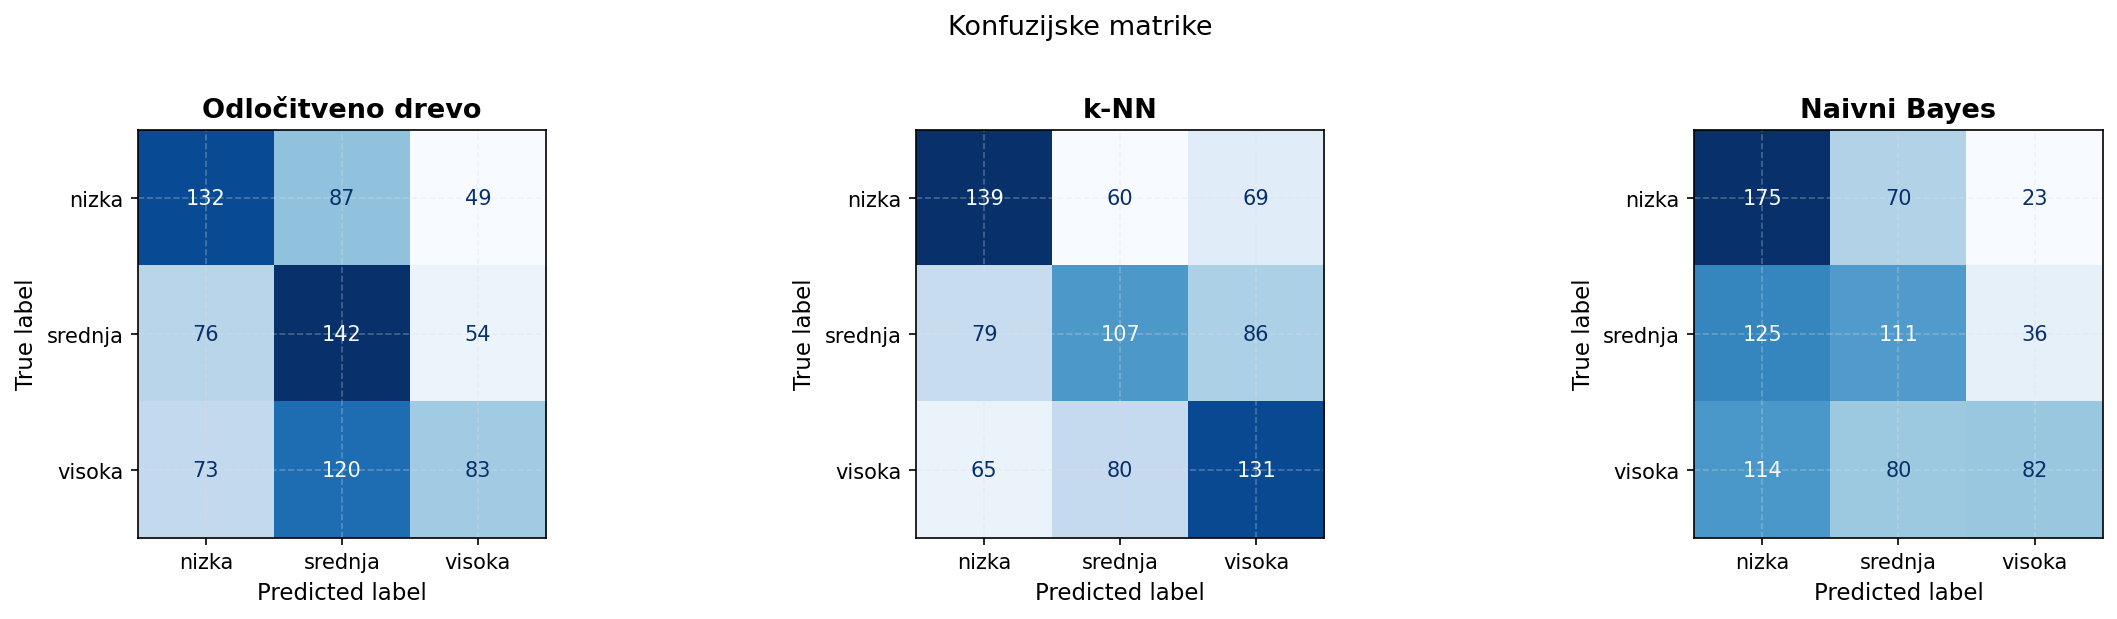

In [42]:
# --- Konfuzijske matrike ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (ime, y_pred) in zip(axes, [
    ("Odločitveno drevo", y_pred_dt),
    ("k-NN",             y_pred_knn),
    ("Naivni Bayes",     y_pred_nb),
]):
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=le_cls.classes_).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(ime, fontweight="bold")
plt.suptitle("Konfuzijske matrike", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

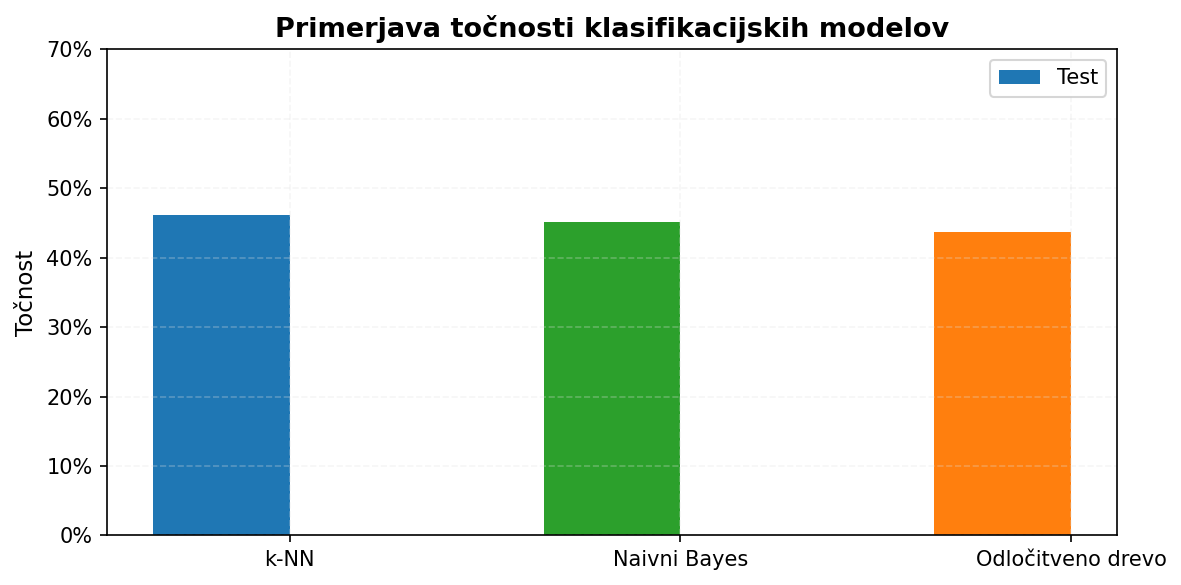

In [43]:
# --- Primerjava točnosti ---
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(rezultati_cls))
w = 0.35
ax.bar(x - w/2, rezultati_cls["Točnost (test)"], w, label="Test",     color=[COLORS[0], COLORS[2], COLORS[1]])
ax.set_xticks(x)
ax.set_xticklabels(rezultati_cls["Model"])
ax.set_ylabel("Točnost")
ax.set_title("Primerjava točnosti klasifikacijskih modelov")
ax.set_ylim(0, 0.7)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.show()

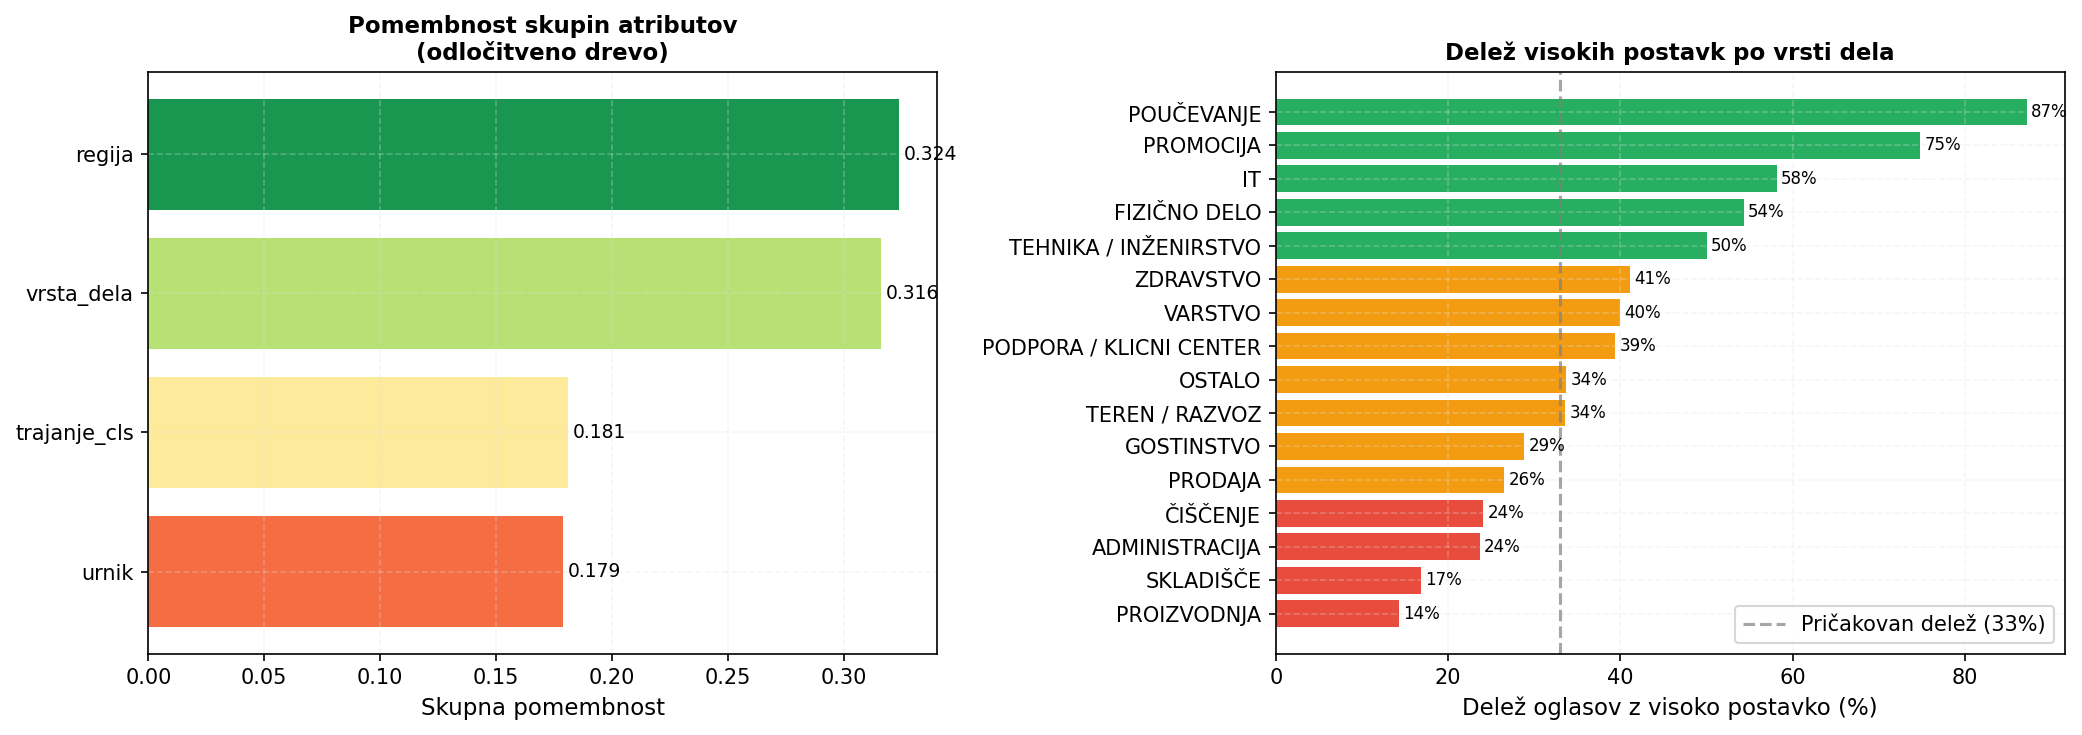

In [44]:
# --- Pomembnost atributov ---
importances = pd.Series(dt_model.feature_importances_, index=X.columns)
importances = importances[importances > 0]

# Grupiramo po izvornem atributu
def izvorni(col):
    for f in features:
        if col.startswith(f): return f
    return col

grouped_imp = importances.copy()
grouped_imp.index = [izvorni(c) for c in grouped_imp.index]
grouped_imp = grouped_imp.groupby(level=0).sum().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cmap = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(grouped_imp)))
axes[0].barh(grouped_imp.index, grouped_imp.values, color=cmap)
axes[0].set_title("Pomembnost skupin atributov\n(odločitveno drevo)", fontsize=11)
axes[0].set_xlabel("Skupna pomembnost")
for i, v in enumerate(grouped_imp.values):
    axes[0].text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=9)

# Delež visokih postavk po vrsti dela
visoke_del = hourly_cls[hourly_cls["razred"] == "visoka"].groupby("vrsta_dela").size()
skupaj_del = hourly_cls.groupby("vrsta_dela").size()
delez = (visoke_del / skupaj_del * 100).fillna(0).sort_values()
bar_colors = ["#e74c3c" if v < 25 else "#f39c12" if v < 45 else "#27ae60" for v in delez.values]
bars = axes[1].barh(delez.index, delez.values, color=bar_colors)
axes[1].axvline(33, color="gray", linestyle="--", alpha=0.7, label="Pričakovan delež (33%)")
axes[1].set_title("Delež visokih postavk po vrsti dela", fontsize=11)
axes[1].set_xlabel("Delež oglasov z visoko postavko (%)")
axes[1].legend()
for bar, val in zip(bars, delez.values):
    axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2, f"{val:.0f}%", va="center", fontsize=8)

plt.tight_layout()
plt.show()

#### Najpogostejše kombinacije atributov pri visoko plačanih delih

Spodnja analiza prikaže kombinacije atributov, ki se najpogosteje pojavljajo pri oglasih z visoko urno postavko. Tako lahko lažje razumemo, kateri tipi del, urniki in regije so povezani z višjim plačilom.


In [46]:
# Najpogostejše kombinacije atributov pri visoko plačanih delih

high_paid = hourly_cls[hourly_cls["razred"] == "visoka"]

kombinacije = (
    high_paid
    .groupby([
        "urnik",
        "trajanje_cls",
        "vrsta_dela",
        "regija"
    ])
    .size()
    .reset_index(name="Število oglasov")
    .sort_values("Število oglasov", ascending=False)
    .head(10)
)

display(kombinacije)


,urnik,trajanje_cls,vrsta_dela,regija,Število oglasov
25,DOPOLDAN,DALJ_ČAS,OSTALO,OSREDNJESLOVENSKA,56
139,IZMENSKO,DALJ_ČAS,GOSTINSTVO,OSREDNJESLOVENSKA,45
278,PO DOGOVORU,DALJ_ČAS,GOSTINSTVO,OSREDNJESLOVENSKA,44
295,PO DOGOVORU,DALJ_ČAS,OSTALO,OSREDNJESLOVENSKA,32
219,IZMENSKO,PO_DOGOVORU,PRODAJA,OSREDNJESLOVENSKA,24
307,PO DOGOVORU,DALJ_ČAS,PRODAJA,OSREDNJESLOVENSKA,22
164,IZMENSKO,DALJ_ČAS,PRODAJA,OSREDNJESLOVENSKA,22
156,IZMENSKO,DALJ_ČAS,OSTALO,OSREDNJESLOVENSKA,19
422,POPOLDAN,DALJ_ČAS,POUČEVANJE,OSREDNJESLOVENSKA,18
17,DOPOLDAN,DALJ_ČAS,IT,OSREDNJESLOVENSKA,16


### Ugotovitve

In [ ]:
# Tabela točnosti
rezultati_display = pd.DataFrame({
    "Model":          [f"Odločitveno drevo (globina {best_depth})", f"k-NN (k={best_k})", "Naivni Bayes"],
    "Točnost (test)": [f"{acc_dt*100:.1f} %", f"{acc_knn*100:.1f} %", f"{acc_nb*100:.1f} %"],
    "CV točnost (5-fold)": [
        f"{cross_val_score(dt_model,  X, y, cv=10).mean()*100:.1f} %",
        f"{cross_val_score(knn_model, X, y, cv=10).mean()*100:.1f} %",
        f"{cross_val_score(nb_model,  X, y, cv=10).mean()*100:.1f} %",
    ],
})
display(rezultati_display.style.hide(axis="index"))

### Ugotovitve

#### Točnost modelov

Vse tri metode smo testirali na 1.223 oglasih (20 % dataseta). Najboljše rezultate je doseglo **ok-NN z 46.2% točnostjo**. Naključno ugibanje med tremi razredi bi doseglo 33,3 %, torej k-NN pravilno napove razred v **13,4 odstotnih točk več primerov kot naključje** — kar je statistično relevantno, a praktično skromno.

Vredno je povedati, da vsi modeli približno isto pravilno ocenijo razred, zato ne moremo rečti da je eden 100% boljši koker ostala dva.

#### Kateri atributi največ prispevajo k napovedi?

| Atribut | Prispevek |
|---|---|
| Regija | 32,4 % |
| Vrsta dela | 31,6 % |
| Urnik | 18,1 % |
| Trajanje | 17,9 % |

Regija je nekoliko presenetljivo najpomembnejši atribut, vendar to za samo 0.8%, kar pomeni, da tago regija kot vrsto dela, imata velik vpliv na plačo.

#### Katera vrsta dela vodi do visoke postavke?

Poučevanje in Promocija imata najvišji % oglasov, ki spadajo pod visoko plačane, kar se ujema z našo ugotovitvijo pri 9.vprašanju, saj sta te dve področij najbolj plačani. Presenetljivo je pa, da ima Varstvo manj koker 50% objav v visoko, saj je po ocenah 3.najboljše plačano vrsto dela.

**Skupna ugotovitev:** strukturirani atributi zadostujejo za zanesljivo napoved samo pri poučevanju, kjer je signal dovolj močan in vzorec dovolj velik. Pri preostalih kategorijah so razlike premajhne ali vzorci premajhni za trdne zaključke.

## Vprašanje 12: Katere besede v opisu oglasa napovedujejo visoko urno postavko?

### Opis

V vprašanju 11 smo za klasifikacijo uporabili **strukturirane atribute** (vrsta dela, regija, urnik, trajanje). Tu gremo korak dlje: model bo prebral **besedilo opisa oglasa** in na podlagi tega napovedal razred urne postavke.

Pristop: **TF-IDF** (Term Frequency–Inverse Document Frequency) pretvori besedila v numerične vektorje, nato pa jih klasificiramo z **Logistično regresijo** in **Complement Naivnim Bayesom**. Na koncu primerjamo točnost z V11 in identificiramo besede, ki najbolj ločijo med razredi.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Priprava podatkov
hourly_nlp = data[
    (data["normalized_payment_type"] == "HOURLY") &
    (data["hourly_rate_neto"].notna())
].copy()

p99_nlp = hourly_nlp["hourly_rate_neto"].quantile(0.99)
hourly_nlp = hourly_nlp[hourly_nlp["hourly_rate_neto"] <= p99_nlp]
q33_nlp = hourly_nlp["hourly_rate_neto"].quantile(0.33)
q66_nlp = hourly_nlp["hourly_rate_neto"].quantile(0.66)

hourly_nlp["razred"] = hourly_nlp["hourly_rate_neto"].apply(
    lambda x: "nizka" if x < q33_nlp else ("srednja" if x <= q66_nlp else "visoka")
)

# Naslov + opis skupaj
hourly_nlp["text"] = hourly_nlp["title"].fillna("") + " " + hourly_nlp["description"].fillna("")
df_nlp = hourly_nlp[["text", "razred"]].dropna()

display(Markdown(f"Oglasov za NLP analizo: **{len(df_nlp):,}**"))

slo_stop = [
    "in","za","na","je","ki","se","so","da","po","pri","ter","ali","bi","ne",
    "iz","ob","do","ta","to","te","ti","pa","bo","ni","ko","mu","ga","jo",
    "med","nad","pod","pred","brez","vse","vsi","ves","vsak","samo","tudi",
    "lahko","zelo","malo","bila","bili","bil","ima","imajo","tega","temu","tem",
    "primeru","čaka","uro","čas","iščeš","vabi","vsaj","takoj","času","drugo","opis", "ka",
    "ica",

    # številke kot stringi
    "0","1","2","3","4","5","6","7","8","9",
    "10","11","12","13","14","15","16","17","18","19",
    "20","21","22","23","24","25","26","27","28","29",
    "30","31","32","33","34","35","36","37","38","39",
    "40","41","42","43","44","45","46","47","48","49",
    "50","51","52","53","54","55","56","57","58","59",
    "60","61","62","63","64","65","66","67","68","69",
    "70","71","72","73","74","75","76","77","78","79",
    "80","81","82","83","84","85","86","87","88","89",
    "90","91","92","93","94","95","96","97","98","99",
    "100"
]

tfidf_v = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 3),
    min_df=30,
    sublinear_tf=True,
    stop_words=slo_stop
)
X_nlp = tfidf_v.fit_transform(df_nlp["text"])
le_nlp = LabelEncoder()
y_nlp = le_nlp.fit_transform(df_nlp["razred"])


X_tr, X_te, y_tr, y_te = train_test_split(
    X_nlp, y_nlp, test_size=0.2, random_state=52, stratify=y_nlp
)
print(f"Train: {len(y_tr)}, Test: {len(y_te)}, Besed/n-gramov: {X_nlp.shape[1]:,}")

### Modeli in evalvacija

In [ ]:
lr_nlp  = LogisticRegression(max_iter=1000, random_state=42, C=1.0).fit(X_tr, y_tr)
mnb_nlp = MultinomialNB(alpha=0.1).fit(X_tr, y_tr)

y_pred_lr  = lr_nlp.predict(X_te)
y_pred_mnb = mnb_nlp.predict(X_te)

acc_lr_nlp  = accuracy_score(y_te, y_pred_lr)
acc_mnb_nlp = accuracy_score(y_te, y_pred_mnb)

tabela_acc = pd.DataFrame({
    "Model": [
        "Logistična regresija (TF-IDF) — V12",
        "Multinomial Naivni Bayes (TF-IDF) — V12",
        "Odločitveno drevo (strukturirani attr.) — V11",
        "k-NN (strukturirani attr.) — V11",
        "Naivni Bayes (strukturirani attr.) — V11",
    ],
    "Točnost (test)": [acc_lr_nlp, acc_mnb_nlp, acc_dt, acc_knn, acc_nb],
    "Pristop": ["V12","V12","V11","V11","V11"]
}).sort_values("Točnost (test)", ascending=False)

display(tabela_acc.style.hide(axis="index").format({"Točnost (test)": "{:.1%}"}))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (ime, y_pred) in zip(axes, [
    ("Logistična regresija (TF-IDF)", y_pred_lr),
    ("Multinomial Naivni Bayes (TF-IDF)", y_pred_mnb),
]):
    ConfusionMatrixDisplay(
        confusion_matrix(y_te, y_pred),
        display_labels=le_nlp.classes_
    ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(ime, fontweight="bold")
plt.suptitle("Konfuzijske matrike — NLP modeli (V12)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Analiza: katere besede locijo razrede

In [ ]:
fn = tfidf_v.get_feature_names_out()
razredi_imena = le_nlp.classes_
top_n = 20
barva_map = {"nizka": "#e74c3c", "srednja": "#f39c12", "visoka": "#27ae60"}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (i, cls) in zip(axes, enumerate(razredi_imena)):
    coef = lr_nlp.coef_[i]
    top_idx = np.argsort(coef)[-top_n:][::-1]
    words = [fn[j] for j in top_idx]
    vals  = [coef[j] for j in top_idx]
    ax.barh(words[::-1], vals[::-1], color=barva_map[cls])
    ax.set_title(f"Razred: {cls.upper()}", fontweight="bold", fontsize=12)
    ax.set_xlabel("Koeficient (LogReg)")
    ax.axvline(0, color="gray", linewidth=0.8)
plt.suptitle("Top 15 besed/n-gramov po razredu urne postavke", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
primerjava = pd.DataFrame({
    "Model": [
        "V11 — Naivni Bayes (strukturirani attr.)",
        "V11 — k-NN (strukturirani attr.)",
        "V11 — Odločitveno drevo (strukturirani attr.)",
        "V12 — Multinomial NB (TF-IDF)",
        "V12 — Logistična regresija (TF-IDF)",
    ],
    "Tocnost": [acc_nb, acc_knn, acc_dt, acc_mnb_nlp, acc_lr_nlp],
    "Pristop": ["V11","V11","V11","V12","V12"]
}).sort_values("Tocnost")

colors_bar = [COLORS[0] if p == "V11" else COLORS[2] for p in primerjava["Pristop"]]
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(primerjava["Model"], primerjava["Tocnost"], color=colors_bar)
ax.set_xlabel("Točnost")
ax.set_title("Primerjava: strukturirani atributi (V11) vs. besedilo oglasa (V12)")
ax.set_xlim(0, 0.75)
ax.axvline(1/3, color="gray", linestyle="--", alpha=0.6)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=COLORS[0], label="V11 — strukturirani atributi"),
    Patch(color=COLORS[2], label="V12 — besedilo (TF-IDF)"),
    plt.Line2D([0],[0], color="gray", linestyle="--", label="Naključje (33,3 %)"),
])
for bar, val in zip(ax.patches[:5], primerjava["Tocnost"]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val*100:.1f} %", va="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.show()

### Ugotovitve

#### Točnost NLP modelov
modela učenja za V12 nista neizmerno boljša koker modeli za V11. Določeni parametri omogočijo, da V12 modela, narasteta na natančnost čez 50%, vredno je omeniti, da skoraj vedno sta modela V12 bolj natančna koker modeli iz V11, kar nam pove, da lahko iz opisa dela bolje ocenimo natančnost plače, kokr iz posameznih atributov. npr. če pomanjšamo število minimalnih pojavitev besede na oglas in povečamo število besed, ki se jih model zapomne dobimo boljšo natančn ost, kokr, če damo manjšo mejo pojavitev in shranjevanja.

#### Katere besede v opisih napovedujejo visoko postavko?

Iz koeficientov logistične regresije razberemo besede, ki **statistično najpogosteje spremljajo visoko postavko** (na podlagi 6.115 oglasov):

**Visoka postavka** — najmočnejši signali:
- *poučevanje* (koef. 2,59) — daleč najmočnejša posamična beseda v celotnem modelu
- *trženje, promocija, pospeševanje prodaje* — specializirano trženjsko delo
- *izobraževanja, medicine* — specifična strokovna področja

**Nizka postavka** — najmočnejši signali:
- *trgovini, prodaji, pomoč prodaji* — splošno maloprodajno delo
- *oblačili, deklariranje, inventura* — fizično, nespecializirano delo
